# data importation & initial visualization

In [ ]:
# Step 1: Install kagglehub if not already installed
!pip install -q kagglehub

import pandas as pd
import os
import shutil
import kagglehub
from google.colab import drive

# Step 2: Mount Google Drive
# This will ask for permission to access your Drive files
drive.mount('/content/drive')

# Step 3: Define your specific path
# "Mon Drive" in the UI maps to "MyDrive" in the file system
folder_path = '/content/drive/MyDrive/rai_hec'
file_name = 'Suicide_Detection.csv' # The standard filename for this dataset
full_path = os.path.join(folder_path, file_name)

# Step 4: Logic to Check, Download, and Move if necessary
if os.path.exists(full_path):
    print(f"✅ Found the file at: {full_path}")
else:
    print(f"❌ File not found in {folder_path}. Downloading now...")

    # Create the directory if it doesn't exist
    os.makedirs(folder_path, exist_ok=True)

    # Download using the snippet you provided
    print("⬇️ Downloading via kagglehub...")
    cache_path = kagglehub.dataset_download("nikhileswarkomati/suicide-watch")

    # Find the CSV file in the downloaded cache
    downloaded_files = os.listdir(cache_path)
    csv_source = [f for f in downloaded_files if f.endswith('.csv')][0]
    source_path = os.path.join(cache_path, csv_source)

    # Copy it to your Drive folder
    print(f"📂 Copying to your Drive folder: {folder_path}...")
    shutil.copy(source_path, full_path)
    print("✅ Copy complete.")

# Step 5: Read the data
print("\n📊 Loading DataFrame...")
df = pd.read_csv(full_path)

# Quick check to ensure it worked
print(f"Data Shape: {df.shape}")
df.head()

Mounted at /content/drive
✅ Found the file at: /content/drive/MyDrive/rai_hec/Suicide_Detection.csv

📊 Loading DataFrame...
Data Shape: (232074, 3)


,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from cycler import cycler

HEC_BLUE = "#013365"
MILA_PURPLE = "#6e006e"
HEC_MILA_PALETTE = [HEC_BLUE, MILA_PURPLE]
HEC_MILA_TRIPLE = [HEC_BLUE, MILA_PURPLE, HEC_BLUE]
HEC_MILA_CMAP = LinearSegmentedColormap.from_list("hec_mila", HEC_MILA_PALETTE)

sns.set_theme(style="whitegrid", palette=HEC_MILA_PALETTE)
plt.rcParams["axes.prop_cycle"] = cycler(color=HEC_MILA_PALETTE)


/tmp/ipykernel_589/4078806668.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, ax=axes[0, 0], palette=HEC_MILA_PALETTE)
/tmp/ipykernel_589/4078806668.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='class', y='word_count', data=df, ax=axes[0, 1], palette=HEC_MILA_PALETTE)


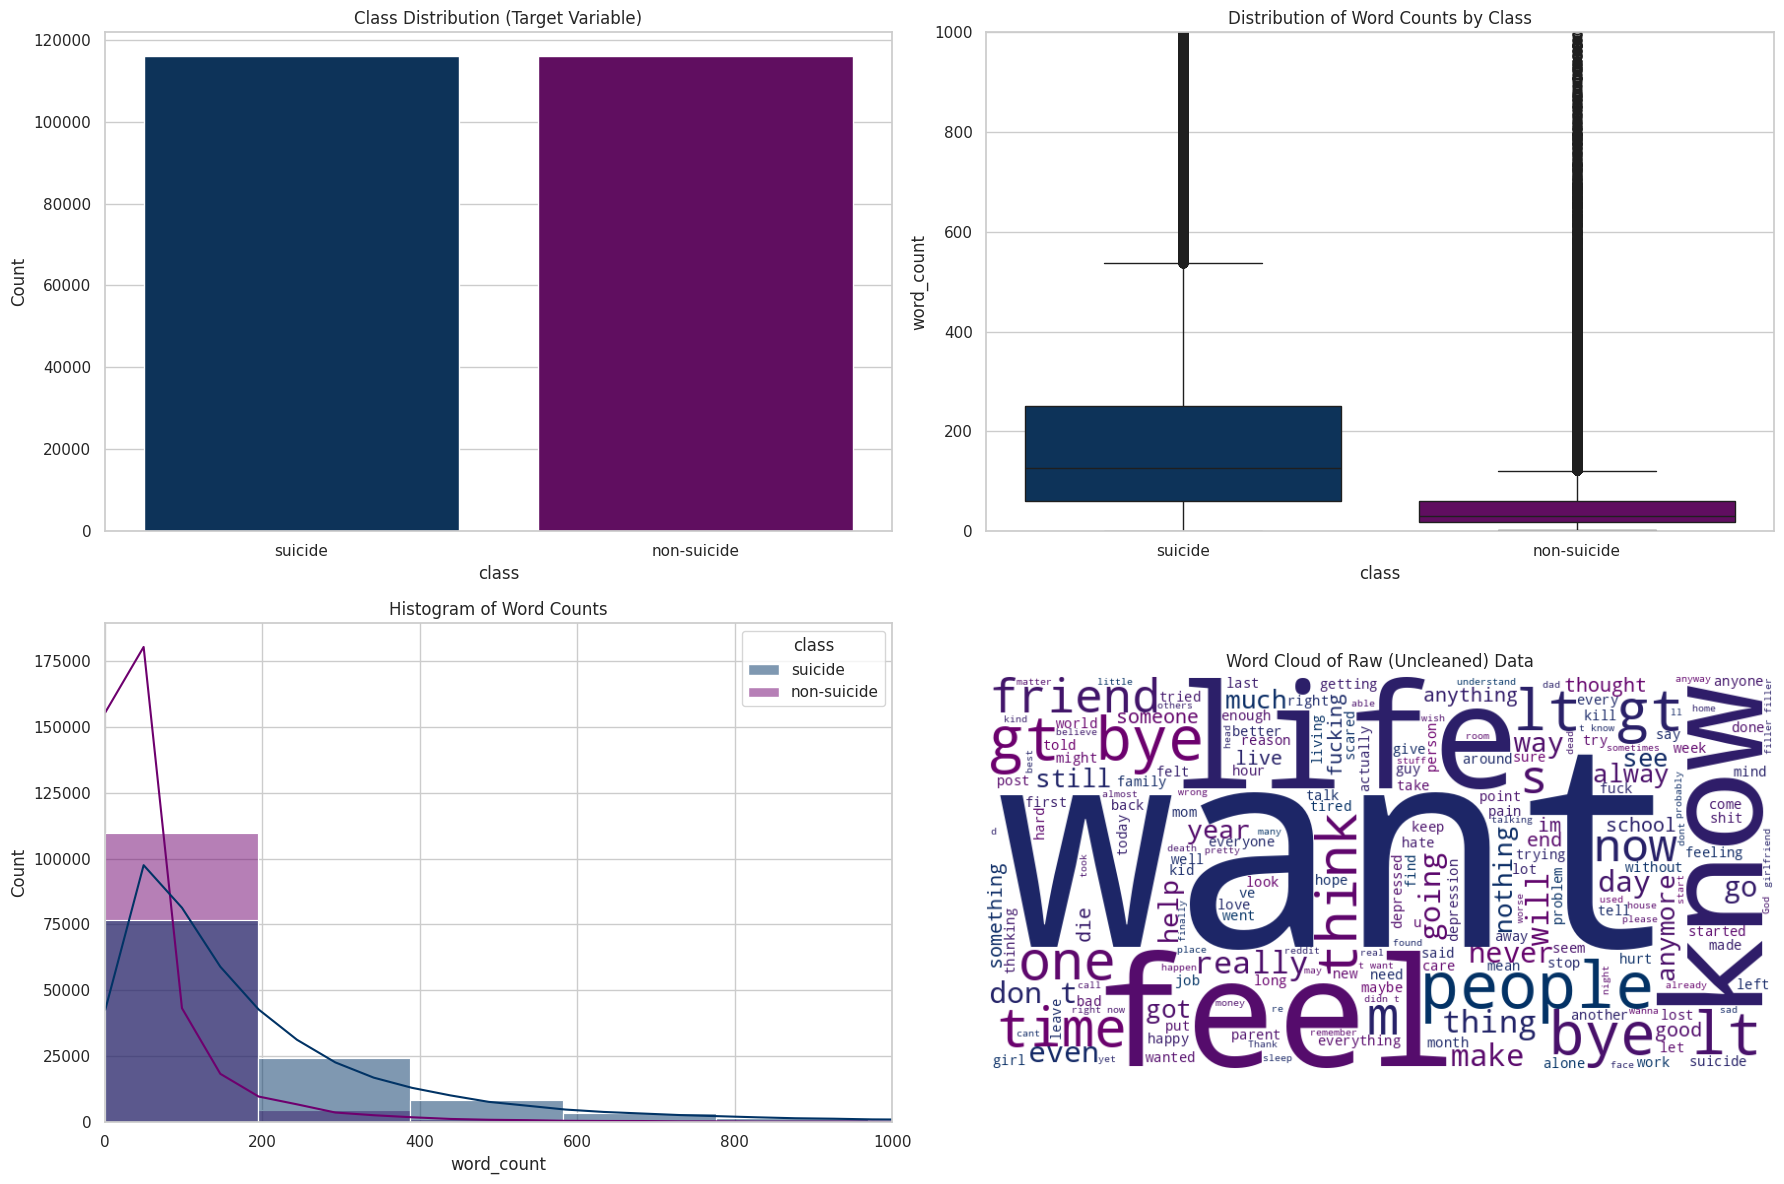

Basic Statistics on Post Lengths:
                count        mean         std  min   25%    50%    75%     max
class                                                                         
non-suicide  116037.0   61.188302  139.292553  2.0  19.0   31.0   60.0  8220.0
suicide      116037.0  202.662168  255.309193  1.0  60.0  127.0  251.0  9684.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set the visual style
sns.set_style("whitegrid")

# 1. Feature Engineering for Visualization
# We create temporary columns just for plotting
df['post_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

# Setup the figure structure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Plot 1: Class Distribution ---
# Check if one class dominates the other (Class Imbalance)
sns.countplot(x='class', data=df, ax=axes[0, 0], palette=HEC_MILA_PALETTE)
axes[0, 0].set_title('Class Distribution (Target Variable)')
axes[0, 0].set_ylabel('Count')

# --- Plot 2: Text Length Distribution (Boxplot) ---
# Check for outliers: Are suicide posts significantly longer/shorter?
# Dots outside the "whiskers" are outliers.
sns.boxplot(x='class', y='word_count', data=df, ax=axes[0, 1], palette=HEC_MILA_PALETTE)
axes[0, 1].set_title('Distribution of Word Counts by Class')
axes[0, 1].set_ylim(0, 1000) # Zoom in: Limit to 1000 words to see the main distribution clearly

# --- Plot 3: Text Length Distribution (Histogram) ---
# See the shape: Is it a normal distribution or skewed?
sns.histplot(data=df, x='word_count', hue='class', kde=True, ax=axes[1, 0], palette=HEC_MILA_PALETTE, bins=50)
axes[1, 0].set_title('Histogram of Word Counts')
axes[1, 0].set_xlim(0, 1000)

# --- Plot 4: Raw Data Word Cloud (Subset) ---
# Quick look at the most common "Raw" words (likely stopwords like 'the', 'to', 'and')
# This confirms we NEED to remove stopwords later.
text_sample = " ".join(df['text'].astype(str).sample(1000)) # Sample 1000 rows for speed
wc = WordCloud(width=800, height=400, background_color='white', colormap=HEC_MILA_CMAP).generate(text_sample)
axes[1, 1].imshow(wc, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('Word Cloud of Raw (Uncleaned) Data')

plt.tight_layout()
plt.show()

# --- Numeric Summary ---
print("Basic Statistics on Post Lengths:")
print(df.groupby('class')['word_count'].describe())

In [ ]:
import re

# Re-define the cleaning function to fix "grafted I" artifacts
def quick_clean(text):
    text = str(text)
    # Fix "dieI" -> "die I" (camelCase split)
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    return text

print("🧹 Re-generating 'text_clean' column...")
df['text_clean'] = df['text'].apply(quick_clean)
print("✅ Text cleaned. Ready for A100 inference.")

🧹 Re-generating 'text_clean' column...
✅ Text cleaned. Ready for A100 inference.


# uni to hexagram patterns

🔄 Calculating Log-Odds & Stats for UNIGRAMS (n=1)...
   --> Computing significance tests for top 40 features...


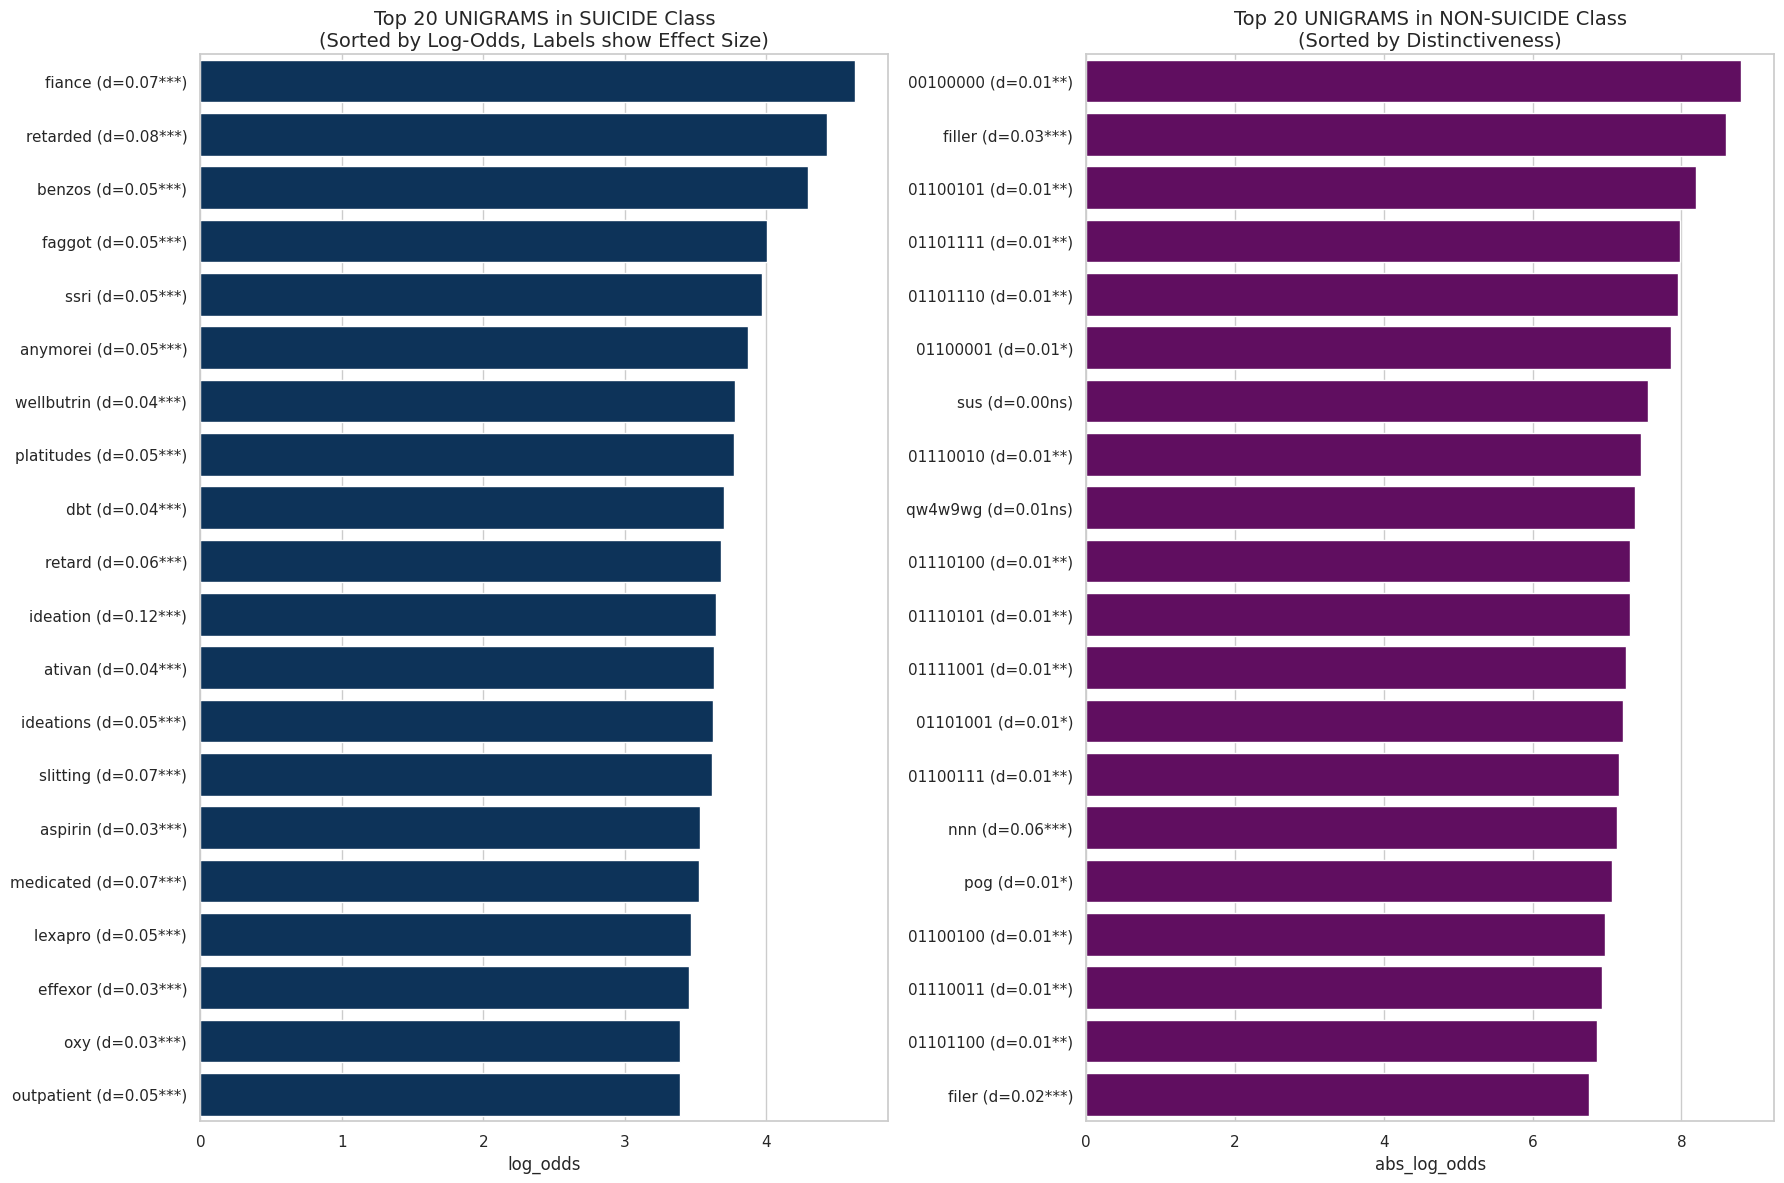

🔄 Calculating Log-Odds & Stats for BIGRAMS (n=2)...
   --> Computing significance tests for top 40 features...


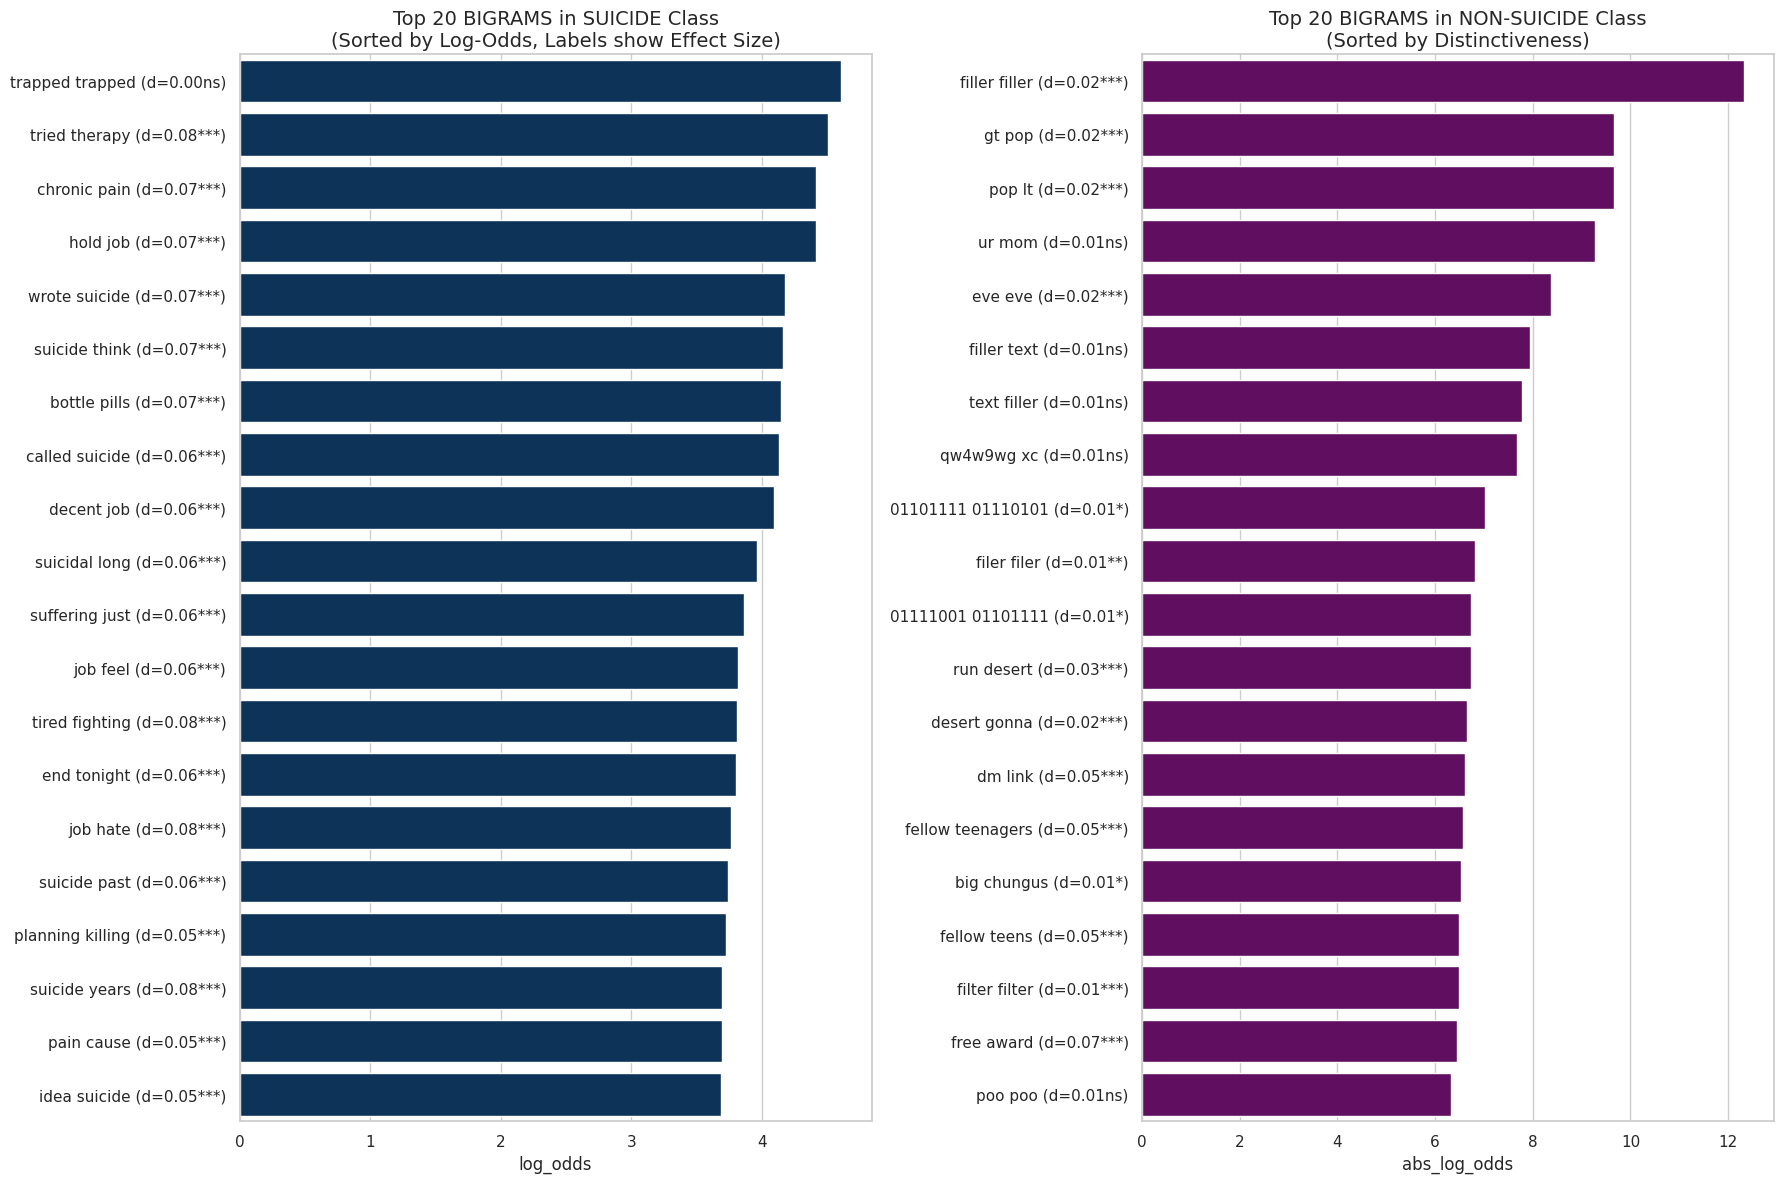

🔄 Calculating Log-Odds & Stats for TRIGRAMS (n=3)...
   --> Computing significance tests for top 40 features...


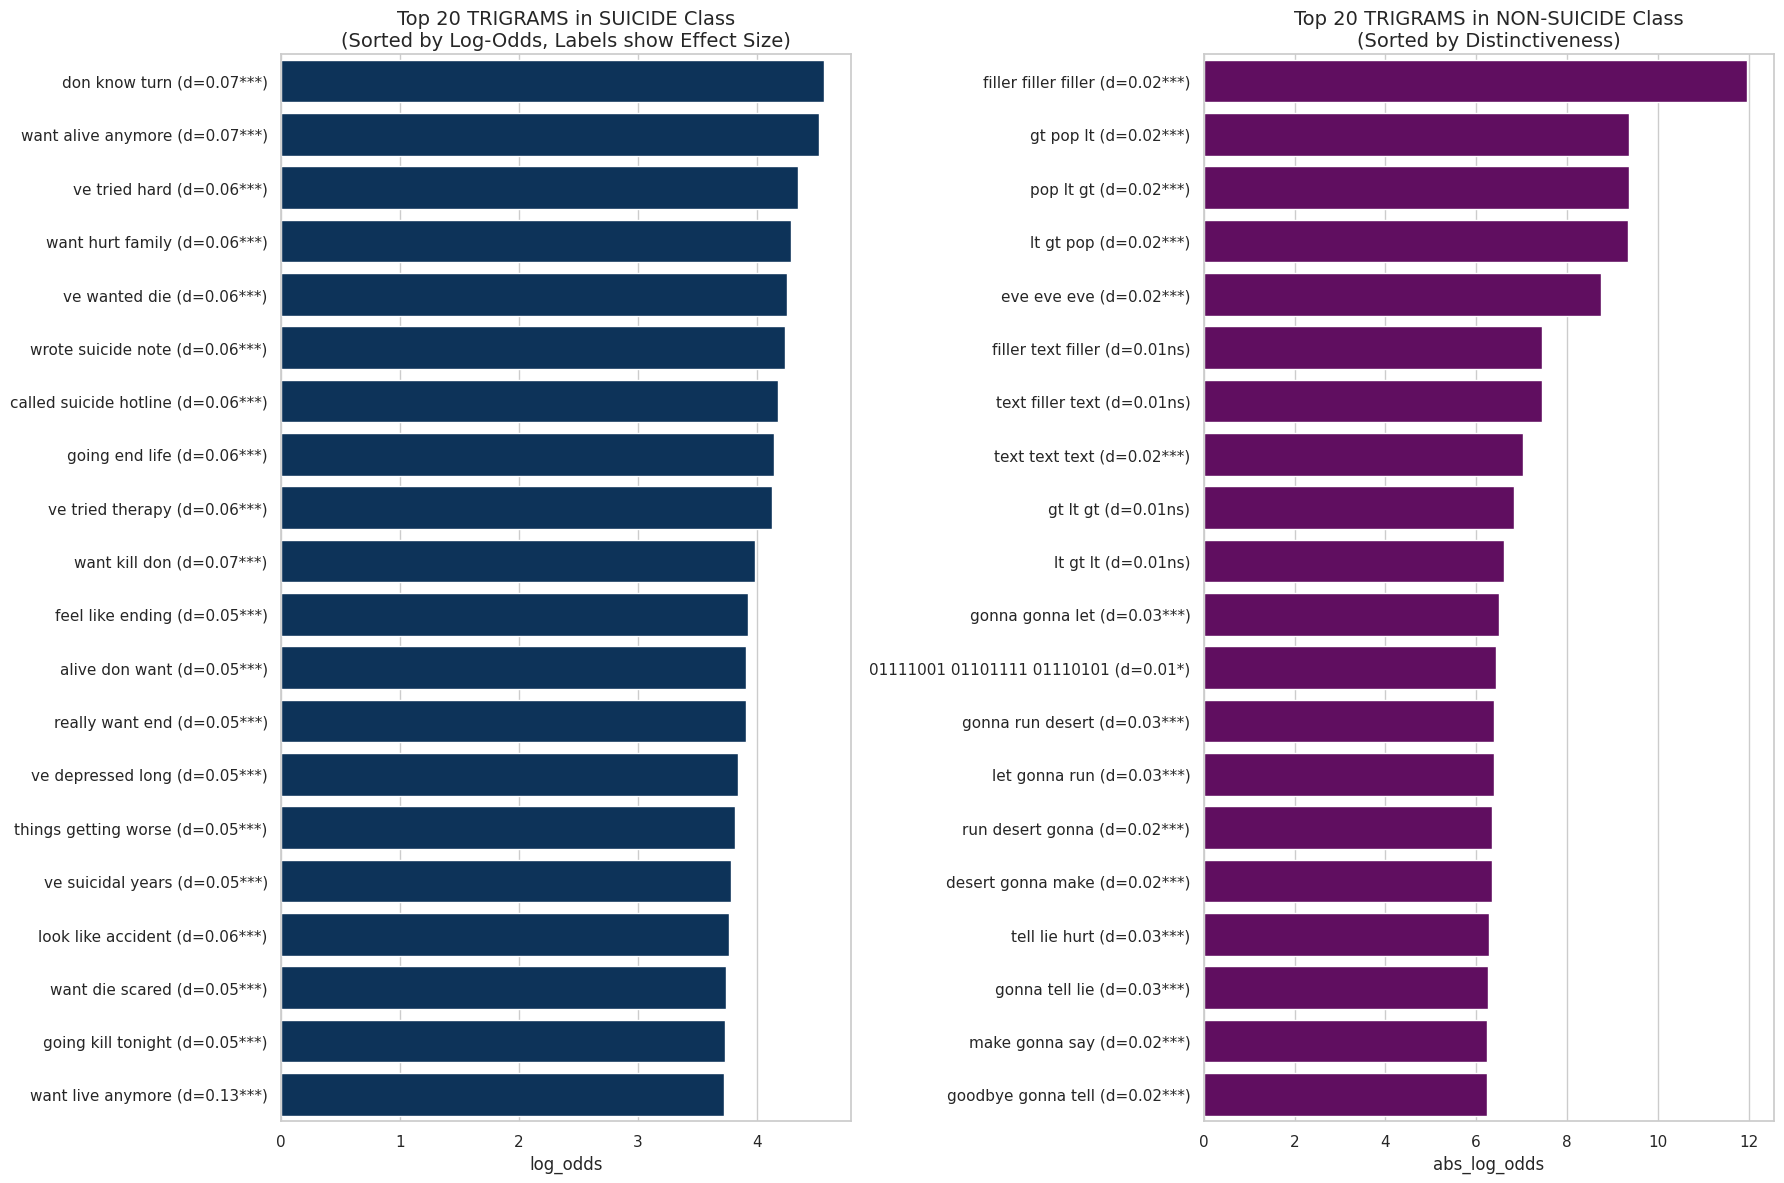

🔄 Calculating Log-Odds & Stats for TETRAGRAMS (n=4)...
   --> Computing significance tests for top 40 features...


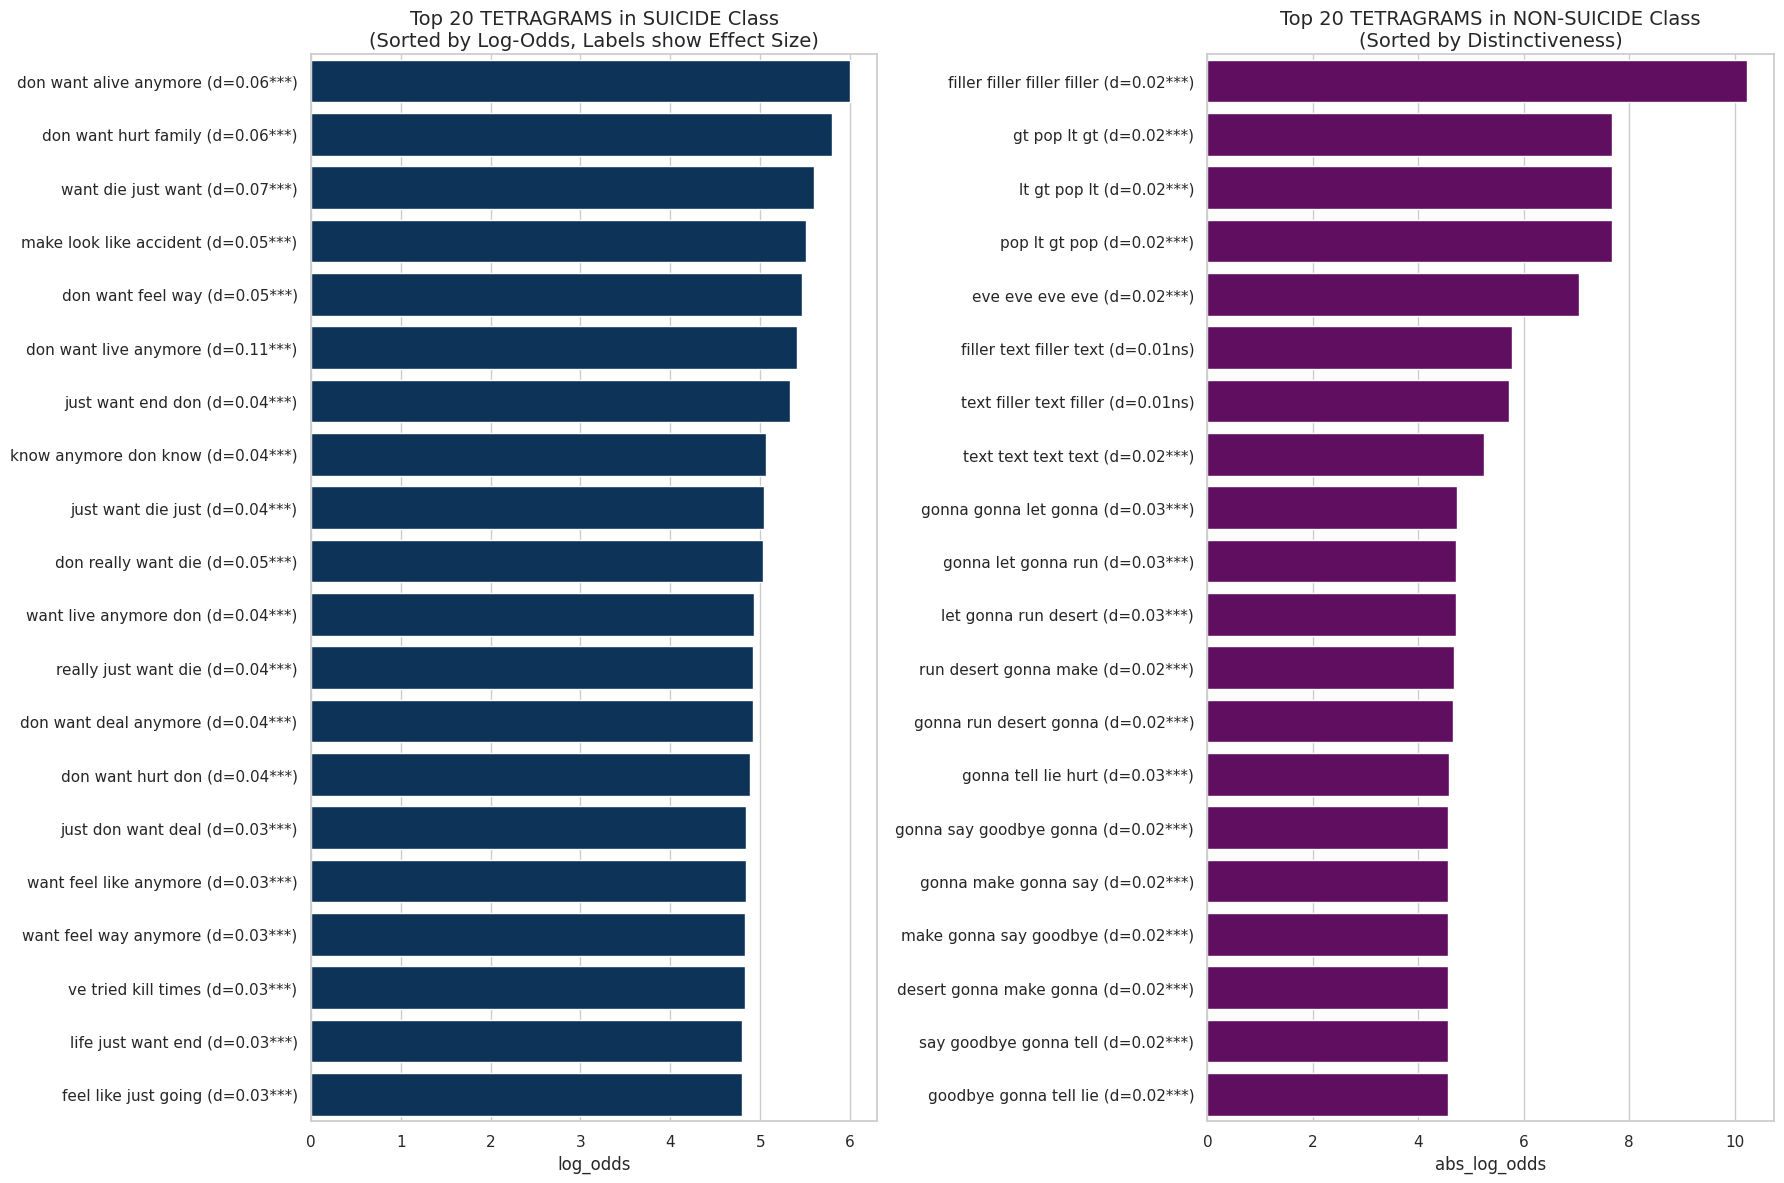

🔄 Calculating Log-Odds & Stats for PENTAGRAMS (n=5)...
   --> Computing significance tests for top 40 features...


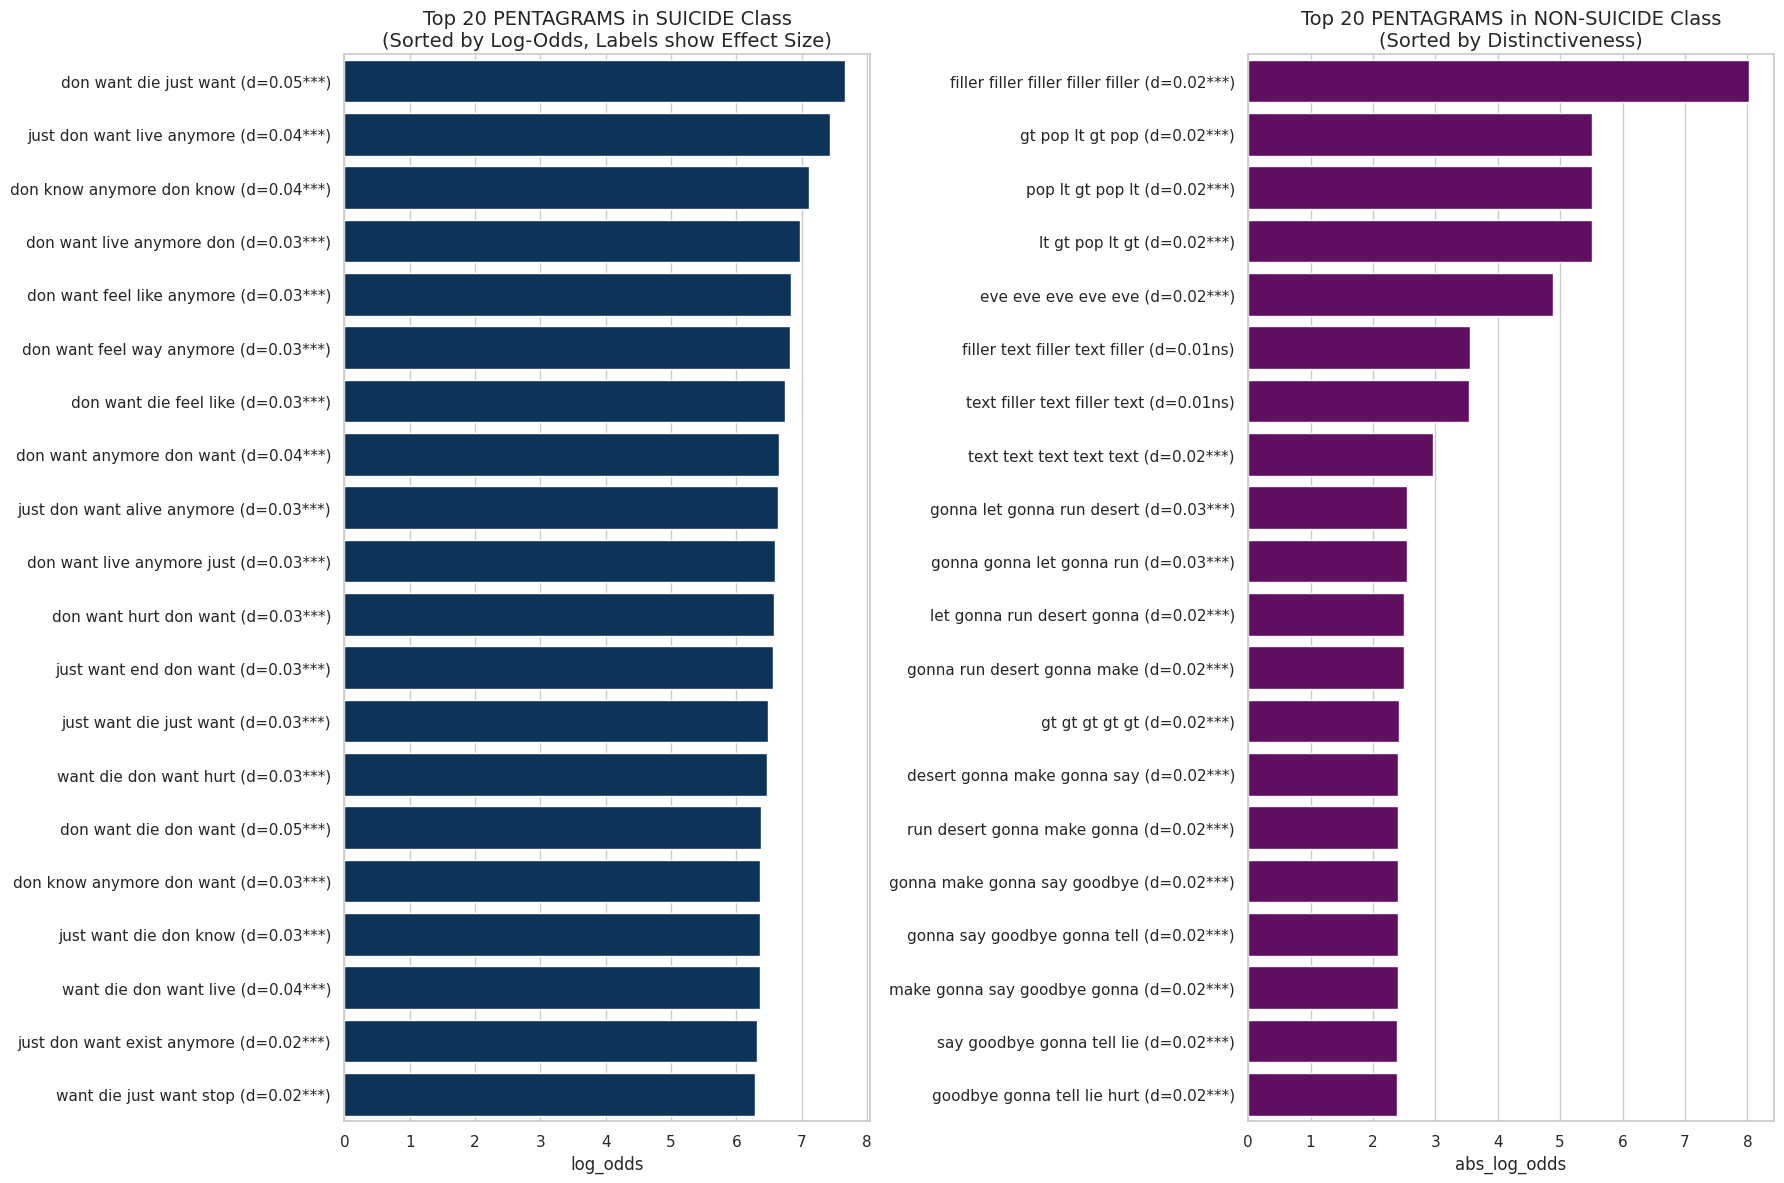

🔄 Calculating Log-Odds & Stats for HEXAGRAMS (n=6)...
   --> Computing significance tests for top 40 features...


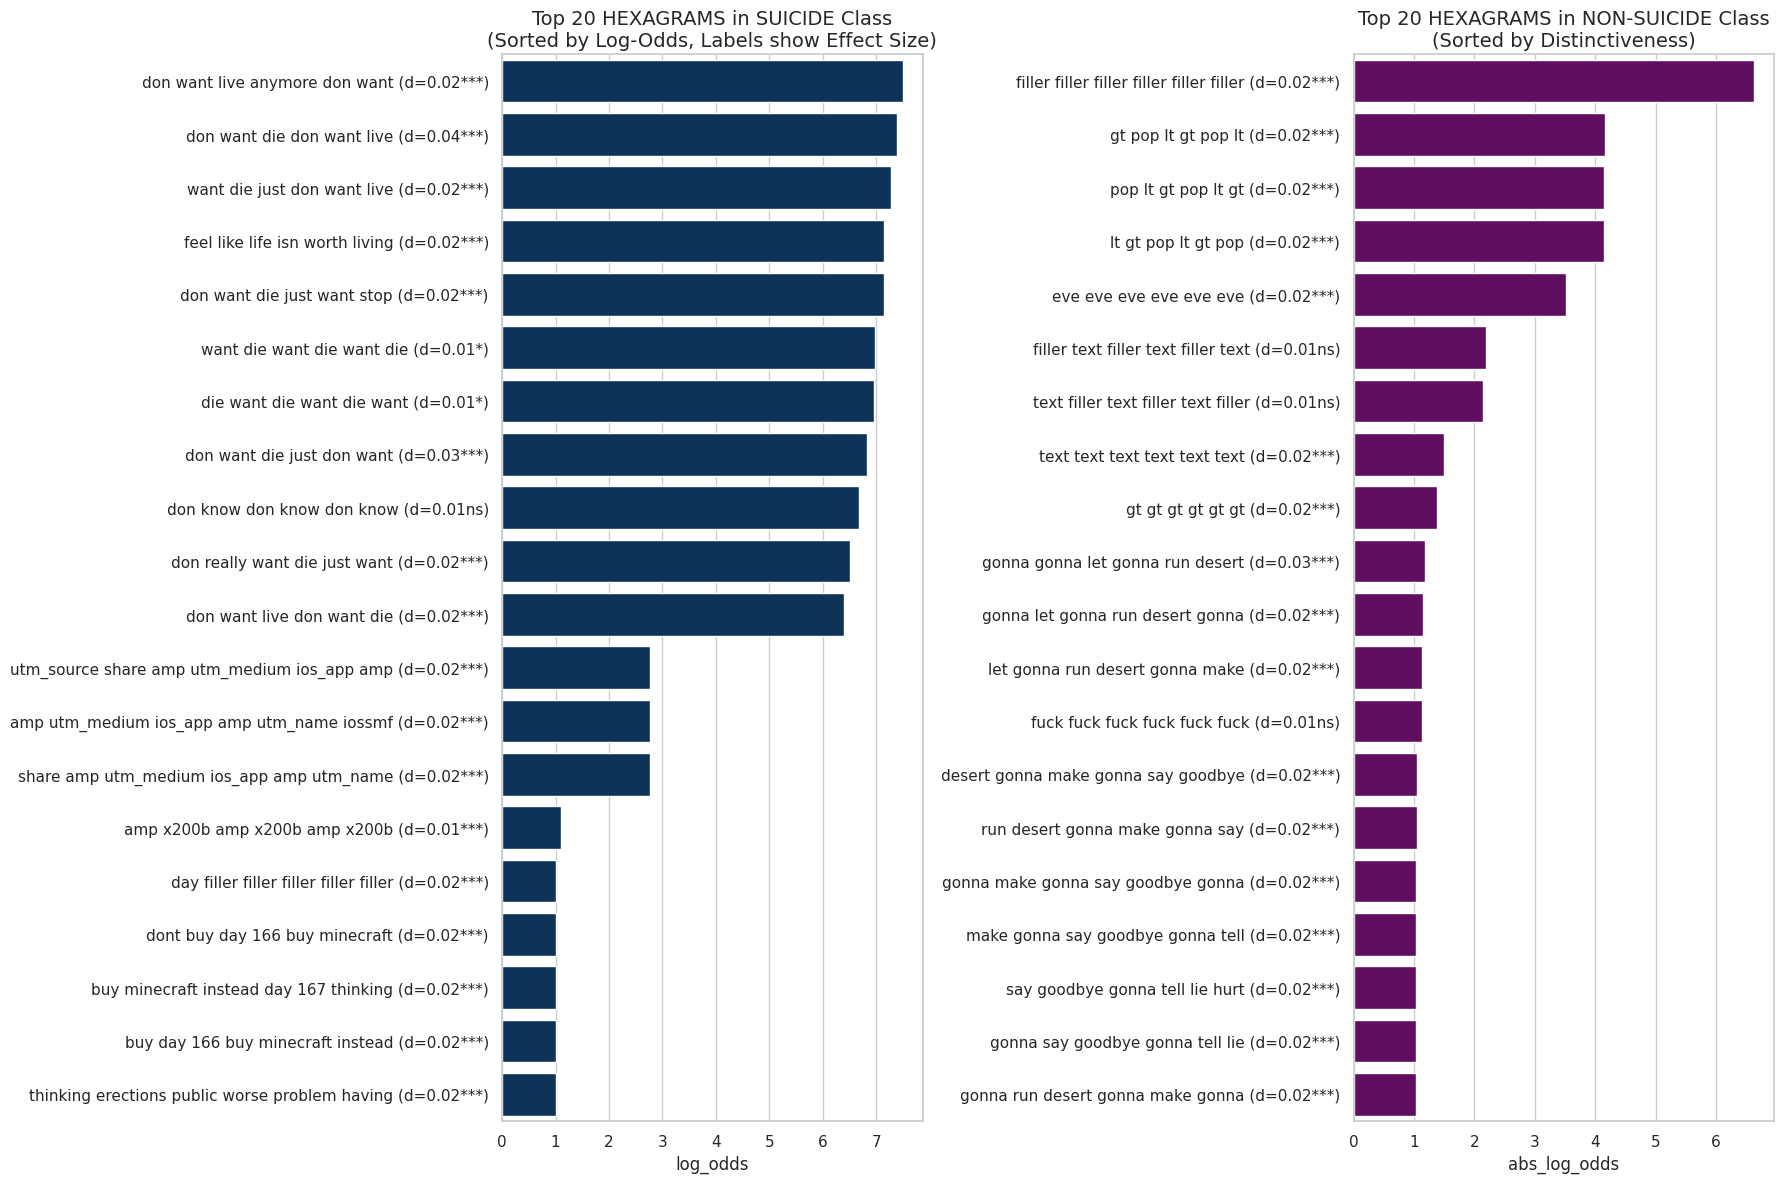

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def analyze_and_plot_ngrams(df, n=3, text_col='text_clean'):
    """
    Generates Log-Odds plots with Statistical Significance and Effect Size.
    """
    gram_name = {1: "UNIGRAMS", 2: "BIGRAMS", 3: "TRIGRAMS", 4: "TETRAGRAMS", 5: "PENTAGRAMS", 6: "HEXAGRAMS"}[n]
    print(f"🔄 Calculating Log-Odds & Stats for {gram_name} (n={n})...")

    # 1. Vectorize
    # Increase min_df to ensure we have enough data points for a valid T-test
    vec = CountVectorizer(stop_words='english', ngram_range=(n, n), min_df=20, max_features=10000)

    try:
        X = vec.fit_transform(df[text_col])
    except ValueError:
        print(f"⚠️ Not enough repeating {gram_name} found. Try lowering min_df.")
        return

    vocab = vec.get_feature_names_out()
    # Create a mapping from word -> column index for fast lookup
    vocab_idx = {word: i for i, word in enumerate(vocab)}

    # 2. Split Classes
    y = df['class'].values
    # Get boolean masks for slicing the sparse matrix later
    mask_suicide = (y == 'suicide')
    mask_nonsuicide = (y == 'non-suicide')

    # 3. Smoothed Counts for Log-Odds
    X_suicide_sum = X[mask_suicide].sum(axis=0).A1 + 1
    X_nonsuicide_sum = X[mask_nonsuicide].sum(axis=0).A1 + 1

    total_suicide = X_suicide_sum.sum()
    total_nonsuicide = X_nonsuicide_sum.sum()

    # 4. Log-Odds Calculation
    log_odds = np.log(X_suicide_sum / total_suicide) - np.log(X_nonsuicide_sum / total_nonsuicide)
    results = pd.DataFrame({'gram': vocab, 'log_odds': log_odds})

    # 5. Extract Top Lists
    top_suicide = results.sort_values('log_odds', ascending=False).head(20).copy()
    top_nonsuicide = results.sort_values('log_odds', ascending=True).head(20).copy()

    # --- HELPER: Calculate Stats for specific grams ---
    def add_stats_to_label(row):
        gram = row['gram']
        idx = vocab_idx[gram]

        # Extract the specific column for this n-gram from the sparse matrix
        # This gives us the count of this n-gram in every document
        col_data = X[:, idx].toarray().ravel()

        # Split by class
        s_counts = col_data[mask_suicide]
        ns_counts = col_data[mask_nonsuicide]

        # T-Test
        t_stat, p_val = stats.ttest_ind(s_counts, ns_counts, equal_var=False)

        # Cohen's d
        # Note: N-gram counts are sparse, so d is often small, but relative differences matter
        pooled_std = np.sqrt((np.var(s_counts) + np.var(ns_counts)) / 2)
        if pooled_std == 0:
            d = 0
        else:
            d = (np.mean(s_counts) - np.mean(ns_counts)) / pooled_std

        # Format the label
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"

        # We use absolute d for the label since the plot separates classes already
        return f"{gram} (d={abs(d):.2f}{sig})"

    # 6. Apply Stats to Labels
    print(f"   --> Computing significance tests for top 40 features...")
    top_suicide['gram_label'] = top_suicide.apply(add_stats_to_label, axis=1)
    top_nonsuicide['gram_label'] = top_nonsuicide.apply(add_stats_to_label, axis=1)

    # 7. Plot
    fig, axes = plt.subplots(1, 2, figsize=(18, 12)) # Increased size for text labels

    # Suicide Plot
    sns.barplot(x='log_odds', y='gram_label', data=top_suicide, ax=axes[0], color=HEC_BLUE)
    axes[0].set_title(f'Top 20 {gram_name} in SUICIDE Class\n(Sorted by Log-Odds, Labels show Effect Size)', fontsize=14)
    axes[0].set_ylabel('')

    # Non-Suicide Plot
    top_nonsuicide['abs_log_odds'] = top_nonsuicide['log_odds'].abs()
    sns.barplot(x='abs_log_odds', y='gram_label', data=top_nonsuicide, ax=axes[1], color=MILA_PURPLE)
    axes[1].set_title(f'Top 20 {gram_name} in NON-SUICIDE Class\n(Sorted by Distinctiveness)', fontsize=14)
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

# --- RUN THE ANALYSIS ---
analyze_and_plot_ngrams(df, n=1) # Unigrams
analyze_and_plot_ngrams(df, n=2) # Bigrams
analyze_and_plot_ngrams(df, n=3) # Trigrams
analyze_and_plot_ngrams(df, n=4) # Tetragrams
analyze_and_plot_ngrams(df, n=5) # Pentagrams
analyze_and_plot_ngrams(df, n=6) # Hexagrams


############################################################
ANALYZING 1-GRAMS
############################################################
   --> Vectorizing 1-grams...
📉 Scoring Teenager dataset against 1-gram Index...


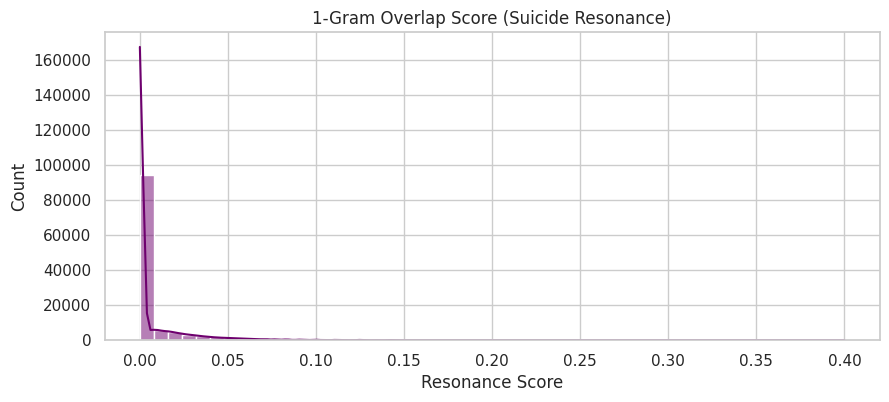

⚠️ Top 3 'Non-Suicidal' posts with HIGHEST 1-Gram Resonance:

--- Score: 0.4000 ---
TEXT: mmmmmmmm manic episode psychosis incoming...


--- Score: 0.3750 ---
TEXT: some desire love, others family i desire [REDACTED]...


--- Score: 0.3333 ---
TEXT: peepee poopoo my dog committed death...


🔍 Analyzing Contexts for Top 5 1-grams...


--- PHRASE: FIANCE ---
🔴 SUICIDE (415 matches):
   ...ted my limits last night, and went on full suicidal plans and thoughts, reached out to my buddy and ___FIANCE___, but i'm still suicidal. I was sitting by the window, ready to jump anytime, but i looked at the te...
   ... off my chest somewhere and I can't think of anywhere else. So here goes:   A couple months ago, my ___FIANCE___ left me. I definitely deserved it, but now I'm struggling to view myself as someone who's worth kee...
   ...nally going to own a house. Why am I still so miserable?I have the hotline on speed dial. I love my ___FIANCE___.   I feel so selfish, but I don't know what to do....

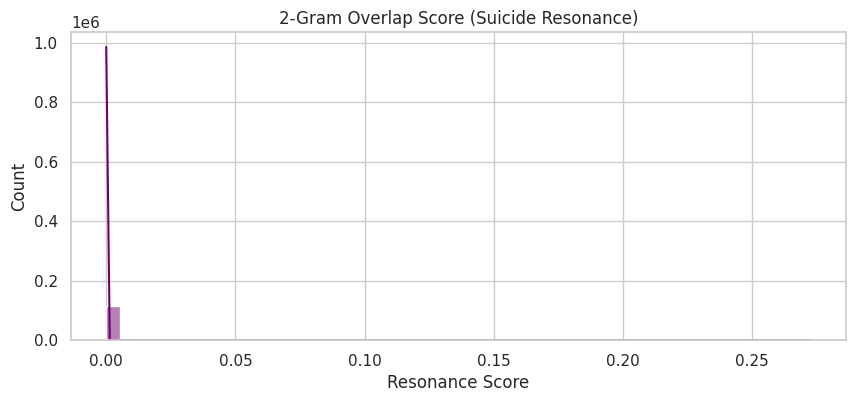

⚠️ Top 3 'Non-Suicidal' posts with HIGHEST 2-Gram Resonance:

--- Score: 0.2727 ---
TEXT: better dead than red better dead than red 

better dead than red...


--- Score: 0.2500 ---
TEXT: i want die :(((((((((((((((((((((( :((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((((...


--- Score: 0.2000 ---
TEXT: helpful advice stop writing suicide notes and start writing your essay...


🔍 Analyzing Contexts for Top 5 2-grams...


--- PHRASE: TRAPPED TRAPPED ---
🔴 SUICIDE (2 matches):
   ...der petals and tongue to cross the synaptic gap between me and the rest of the universe and  i feel ___TRAPPED TRAPPED___ in my own skin and i want to hurt, want to feel something real there is nothing you can do for me i...
   ...___TRAPPED TRAPPED___ ___TRAPPED TRAPPED___ ___TRAPPED TRAPPED___ ___TRAPPED TRAPPED___ ___TRAPPED TRAPPED___ ___TRAPPED TRAPPED___ ___TRAPPED TRAPPED___ Tra...
🟢 NON

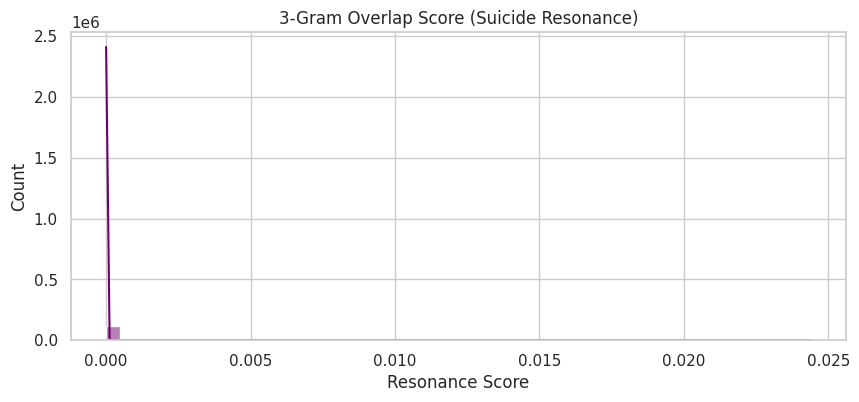

⚠️ Top 3 'Non-Suicidal' posts with HIGHEST 3-Gram Resonance:

--- Score: 0.0244 ---
TEXT: ok but the narcissism that comes with borderline personality disorder on god i either feel like the world is smothering me and im worthless and bad or i feel like i am a complete perfect flawless God ...


--- Score: 0.0179 ---
TEXT: Bein borderline personality disorder sucks. Everyone hates us ahaha Thats why i embrace being an asshole everyone gonna hate me every way.  Everyone hates us even our therapists. At least i am honest ...


--- Score: 0.0091 ---
TEXT: Take your time and read the funniest joke I 've ever heard One day, in philosophy class teacher said to students that "I will ask you three questions and if you answer them correctly I will give you f...


🔍 Analyzing Contexts for Top 5 3-grams...


--- PHRASE: DON KNOW TURN ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (No matches found)

--- PHRASE: WANT ALIVE ANYMORE ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (

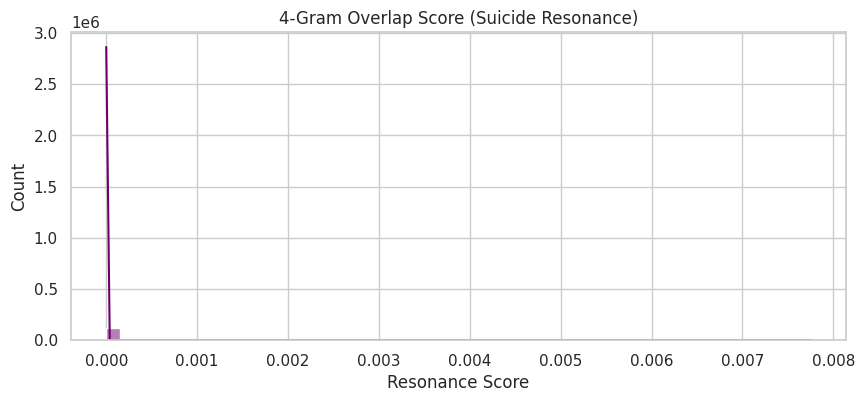

⚠️ Top 3 'Non-Suicidal' posts with HIGHEST 4-Gram Resonance:

--- Score: 0.0078 ---
TEXT: my mom and doctor are forcing to me to eat three meals and a smoothie a day and i cant do i t please help its giving me so much anxiety and im about to panic like ugh i dont want to have a panic attac...


--- Score: 0.0041 ---
TEXT: Should I give up? I’m an 18 year old male and life is hard for me right now. A few weeks ago a girl said she liked me then within a few days said she wanted to take things slower, then yesterday she s...


--- Score: 0.0000 ---
TEXT: Well fuck I told my little sister that I might have a crush on this classmate called Hannah. SHE MIGHT TATTLE CUZ SHE KNOWS WHO HANNAH IS (o shit)...


🔍 Analyzing Contexts for Top 5 4-grams...


--- PHRASE: DON WANT ALIVE ANYMORE ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (No matches found)

--- PHRASE: KILL KILL KILL KILL ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (No matches found)

--- PHRASE: DON WANT HURT

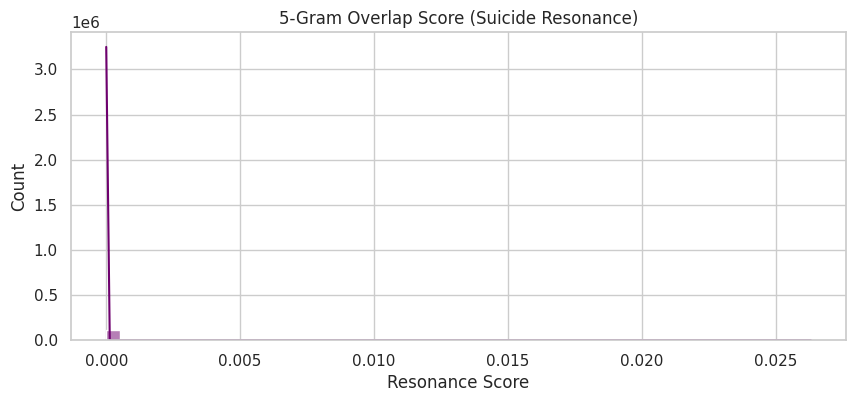

⚠️ Top 3 'Non-Suicidal' posts with HIGHEST 5-Gram Resonance:

--- Score: 0.0263 ---
TEXT: I just got my fly shot and I'm proud. I hate hate hate hate hate needles, but I got my flu shot without crying or anything. I just kinda sat there bit my younger and got the shot. I'm proud of myself....


--- Score: 0.0000 ---
TEXT: Well fuck I told my little sister that I might have a crush on this classmate called Hannah. SHE MIGHT TATTLE CUZ SHE KNOWS WHO HANNAH IS (o shit)...


--- Score: 0.0000 ---
TEXT: Well fuck So im on a discord call with my crush and well, she just called my sister cute, and then proceeded to tell me she is gay, so thats pretty fuckin neat lol, i am gonna go cry now...


🔍 Analyzing Contexts for Top 5 5-grams...


--- PHRASE: KILL KILL KILL KILL KILL ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (No matches found)

--- PHRASE: DON WANT DIE JUST WANT ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (No matches found)

--- PHRASE: JUST DON WANT LIVE ANY

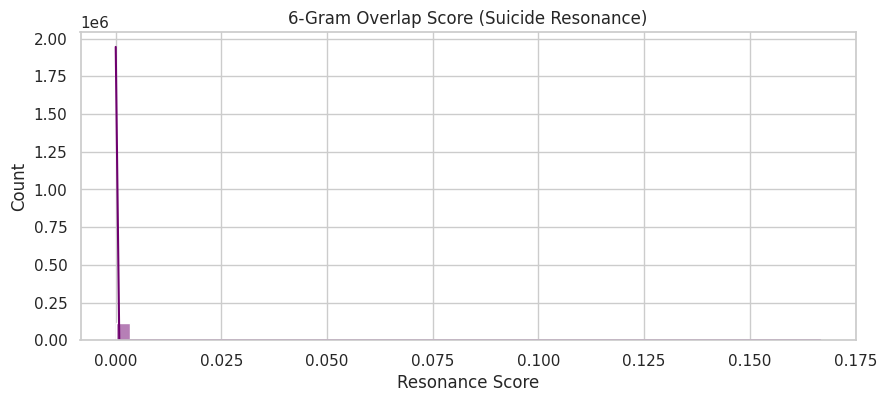

⚠️ Top 3 'Non-Suicidal' posts with HIGHEST 6-Gram Resonance:

--- Score: 0.1667 ---
TEXT: deppresed af ! anyone wanna talk filler filler filler filler filler...


--- Score: 0.1000 ---
TEXT: Stalk my account and judge me Basically the title filler filler filler filler filler filler...


--- Score: 0.0909 ---
TEXT: Fuck private christian schools They scarred me for life filler filler filler filler filler filler filler...


🔍 Analyzing Contexts for Top 5 6-grams...


--- PHRASE: DON WANT LIVE ANYMORE DON WANT ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (No matches found)

--- PHRASE: DON WANT DIE DON WANT LIVE ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (No matches found)

--- PHRASE: WANT DIE JUST DON WANT LIVE ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (No matches found)

--- PHRASE: FEEL LIKE LIFE ISN WORTH LIVING ---
🔴 SUICIDE (0 matches):
🟢 NON-SUICIDE (0 matches):
   (No matches found)

--- PHRASE: DON WANT DIE JUST WANT STOP ---
🔴 SUICIDE (0

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import random
from sklearn.feature_extraction.text import CountVectorizer

# Set seed for full determinism (including example sampling)
random.seed(42)
np.random.seed(42)

# ==============================================================================
# 1. HELPER FUNCTIONS (Define once)
# ==============================================================================

def get_ngram_z_scores(df, n):
    """Calculates Log-Odds for N-grams."""
    print(f"   --> Vectorizing {n}-grams...")
    # Note: min_df=10 helps filtering rare patterns at higher N
    vec = CountVectorizer(stop_words='english', ngram_range=(n, n), min_df=10, max_features=5000)

    try:
        X = vec.fit_transform(df['text_clean'])
    except ValueError:
        # Returns empty if no n-grams meet the criteria (rare for n=6 but possible)
        return None

    vocab = np.array(vec.get_feature_names_out())
    y = df['class']

    # Calculate counts per class
    n_suicide = X[(y == 'suicide').values].sum(axis=0).A1 + 1
    n_nonsuicide = X[(y == 'non-suicide').values].sum(axis=0).A1 + 1

    total_suicide = n_suicide.sum()
    total_nonsuicide = n_nonsuicide.sum()

    log_odds = np.log(n_suicide / total_suicide) - np.log(n_nonsuicide / total_nonsuicide)
    return pd.DataFrame({'gram': vocab, 'log_odds': log_odds})

def calculate_ngram_resonance(text, lexicon, n):
    """Calculates what % of n-grams in text appear in the suicide lexicon."""
    if not isinstance(text, str): return 0
    words = text.split()
    if len(words) < n: return 0

    # Generate N-Grams for this specific text
    ngrams = [" ".join(gram) for gram in zip(*[words[i:] for i in range(n)])]

    match_count = sum(1 for gram in ngrams if gram in lexicon)
    return match_count / len(ngrams)

def get_kwic(text, keyword, window_size=100):
    """Finds keyword in text and returns context window."""
    match = re.search(r'\b' + re.escape(keyword) + r'\b', text, re.IGNORECASE)
    if not match: return None

    start, end = match.span()
    left = max(0, start - window_size)
    right = min(len(text), end + window_size)

    snippet = text[left:right].replace('\n', ' ')
    snippet = re.sub(r'\b' + re.escape(keyword) + r'\b', f"___{keyword.upper()}___", snippet, flags=re.IGNORECASE)
    return "..." + snippet + "..."

# ==============================================================================
# 2. THE LOOP (1, 2, 3, 4, 5, 6)
# ==============================================================================

grams_to_analyze = [1, 2, 3, 4, 5, 6]

for N_VALUE in grams_to_analyze:
    print(f"\n{'#'*60}")
    print(f"ANALYZING {N_VALUE}-GRAMS")
    print(f"{'#'*60}")

    # --- Step 1: Calculate Log Odds ---
    ngram_z_scores = get_ngram_z_scores(df, n=N_VALUE)

    if ngram_z_scores is None or ngram_z_scores.empty:
        print(f"⚠️ Skipped {N_VALUE}-grams: Not enough repeating patterns found.")
        continue

    # --- Step 2: Resonance Analysis (Overlap) ---
    # Extract lexicon (Top 500 suicidal n-grams)
    suicide_lexicon = set(ngram_z_scores.sort_values('log_odds', ascending=False).head(500)['gram'])

    print(f"📉 Scoring Teenager dataset against {N_VALUE}-gram Index...")
    df_teenagers = df[df['class'] == 'non-suicide'].copy()

    # Apply scoring function
    # We pass the 'suicide_lexicon' specifically for this loop iteration
    df_teenagers['resonance'] = df_teenagers['text_clean'].apply(
        lambda x: calculate_ngram_resonance(x, suicide_lexicon, N_VALUE)
    )

    # Plot Resonance
    plt.figure(figsize=(10, 4))
    sns.histplot(df_teenagers['resonance'], bins=50, color=MILA_PURPLE, kde=True)
    plt.title(f'{N_VALUE}-Gram Overlap Score (Suicide Resonance)')
    plt.xlabel('Resonance Score')
    plt.show()

    # Show Top 3 High-Risk Examples
    print(f"⚠️ Top 3 'Non-Suicidal' posts with HIGHEST {N_VALUE}-Gram Resonance:\n")
    high_risk = df_teenagers.sort_values('resonance', ascending=False).head(3)
    for i, row in high_risk.iterrows():
        print(f"--- Score: {row['resonance']:.4f} ---")
        print(f"TEXT: {row['text_clean'][:200]}...")
        print("\n")

    # --- Step 3: Context Analysis (KWIC) ---
    print(f"🔍 Analyzing Contexts for Top 5 {N_VALUE}-grams...\n")

    # Get just the top 5 for brevity in the loop
    top_grams = ngram_z_scores.sort_values('log_odds', ascending=False).head(5)['gram'].tolist()

    for phrase in top_grams:
        print(f"\n--- PHRASE: {phrase.upper()} ---")

        # Filter matches using regex
        # Note: We re-escape the phrase to handle any regex-special chars in the text
        suicide_hits = df[
            (df['class'] == 'suicide') &
            (df['text_clean'].str.contains(r'\b' + re.escape(phrase) + r'\b', case=False))
        ]['text_clean'].tolist()

        teenager_hits = df[
            (df['class'] == 'non-suicide') &
            (df['text_clean'].str.contains(r'\b' + re.escape(phrase) + r'\b', case=False))
        ]['text_clean'].tolist()

        # Deterministic sampling
        s_samples = random.sample(suicide_hits, min(3, len(suicide_hits)))
        t_samples = random.sample(teenager_hits, min(3, len(teenager_hits)))

        print(f"🔴 SUICIDE ({len(suicide_hits)} matches):")
        for text in s_samples:
            print(f"   {get_kwic(text, phrase)}")

        print(f"🟢 NON-SUICIDE ({len(teenager_hits)} matches):")
        if not t_samples:
            print("   (No matches found)")
        else:
            for text in t_samples:
                print(f"   {get_kwic(text, phrase)}")

In [ ]:
# import matplotlib.pyplot as plt
# import networkx as nx
# import pandas as pd
# import numpy as np
# from sklearn.feature_extraction.text import CountVectorizer

# def plot_overlap_network(df, n_gram_range=(2, 3), top_n=30):
#     """
#     Creates a Network Graph showing phrases that act as bridges
#     between Suicide and Non-Suicide classes.
#     """
#     print(f"🕸️ Building Overlap Network for {n_gram_range}-grams...")

#     # 1. Vectorize specifically to find SHARED terms
#     vec = CountVectorizer(ngram_range=n_gram_range, stop_words='english', min_df=50)
#     X = vec.fit_transform(df['text_clean'])
#     vocab = np.array(vec.get_feature_names_out())

#     # 2. Get counts per class
#     y = df['class']
#     s_counts = X[y == 'suicide'].sum(axis=0).A1
#     ns_counts = X[y == 'non-suicide'].sum(axis=0).A1

#     # 3. Create a DataFrame of phrases
#     data = pd.DataFrame({'phrase': vocab, 'suicide': s_counts, 'teenager': ns_counts})

#     # Filter: We only want phrases that appear frequently in BOTH (The Bridge Terms)
#     # We define "Bridge" as having at least 20% representation in the minority class
#     data['total'] = data['suicide'] + data['teenager']
#     data['ratio'] = data['suicide'] / data['total']

#     # Select terms that are ambiguous (ratio between 0.3 and 0.7)
#     # These are the "confusing" terms that overlap the most
#     bridges = data[(data['ratio'] > 0.3) & (data['ratio'] < 0.7)].sort_values('total', ascending=False).head(top_n)

#     # 4. Build the Graph
#     G = nx.Graph()

#     # Add Central Nodes
#     G.add_node("SUICIDE", color=HEC_BLUE, size=3000)
#     G.add_node("TEENAGER", color=MILA_PURPLE, size=3000)

#     # Add Phrase Nodes and Edges
#     for _, row in bridges.iterrows():
#         phrase = row['phrase']
#         # Node size based on frequency
#         G.add_node(phrase, color=HEC_BLUE, size=row['total'] * 0.5)

#         # Edge to Suicide (Weight = count)
#         G.add_edge("SUICIDE", phrase, weight=row['suicide'], color=HEC_BLUE)

#         # Edge to Teenager (Weight = count)
#         G.add_edge("TEENAGER", phrase, weight=row['teenager'], color=MILA_PURPLE)

#     # 5. Plotting
#     plt.figure(figsize=(16, 12))
#     pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42)

#     # Draw Nodes
#     node_sizes = [nx.get_node_attributes(G, 'size').get(n, 500) for n in G.nodes()]
#     node_colors = [nx.get_node_attributes(G, 'color').get(n, 'grey') for n in G.nodes()]

#     nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)

#     # Draw Edges (Thickness based on weight)
#     edges = G.edges()
#     weights = [G[u][v]['weight'] * 0.002 for u, v in edges]
#     edge_colors = [G[u][v]['color'] for u, v in edges]

#     nx.draw_networkx_edges(G, pos, width=weights, edge_color=edge_colors, alpha=0.3)

#     # Labels
#     nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

#     plt.title(f"The 'Ambiguity Cloud': Top {top_n} Shared Phrases\n(Phrases connecting both worlds)", fontsize=16)
#     plt.axis('off')
#     plt.show()

# # Run it
# plot_overlap_network(df)

# pronoun & vocabulary analyses

🧠 PART 1: Discovering Latent Topics (LDA)...

🔍 The 5 Hidden Topics in the Dataset:
   Topic 1: don, want, just, life, know, feel, die, like, ve, anymore
   Topic 2: ve, just, life, like, don, time, feel, years, know, school
   Topic 3: like, just, day, said, got, post, guys, girl, friend, know
   Topic 4: filler, mom, wanna, ur, play, cheese, bored, game, games, music
   Topic 5: just, like, im, fuck, people, feel, know, fucking, don, dont


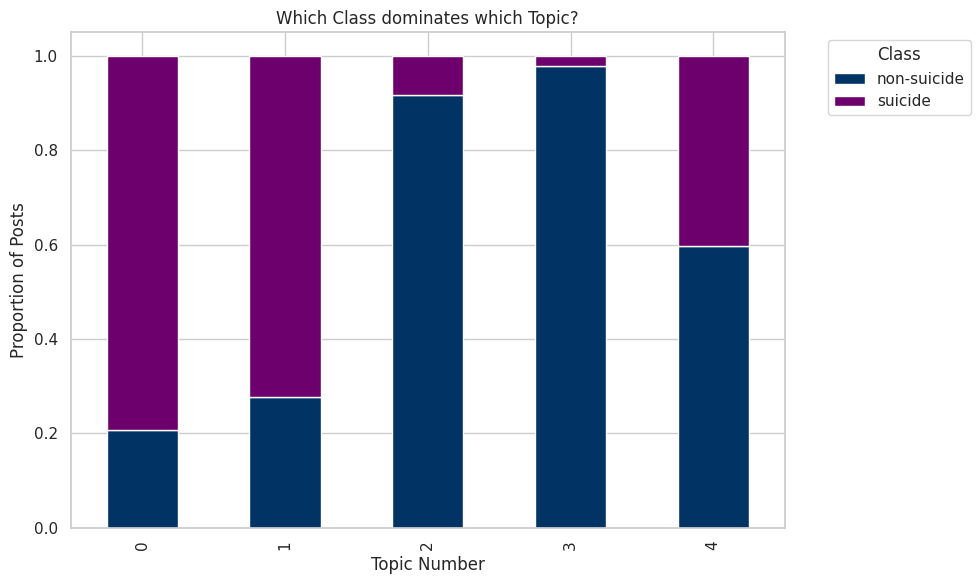


🧠 PART 2: Analyzing Cognitive Markers...


/tmp/ipykernel_589/3720662659.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='self_ref_density', data=df, ax=axes[0], palette=HEC_MILA_PALETTE)
/tmp/ipykernel_589/3720662659.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='social_ref_density', data=df, ax=axes[1], palette=HEC_MILA_PALETTE)
/tmp/ipykernel_589/3720662659.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='absolutist_density', data=df, ax=axes[2], palette=HEC_MILA_PALETTE)


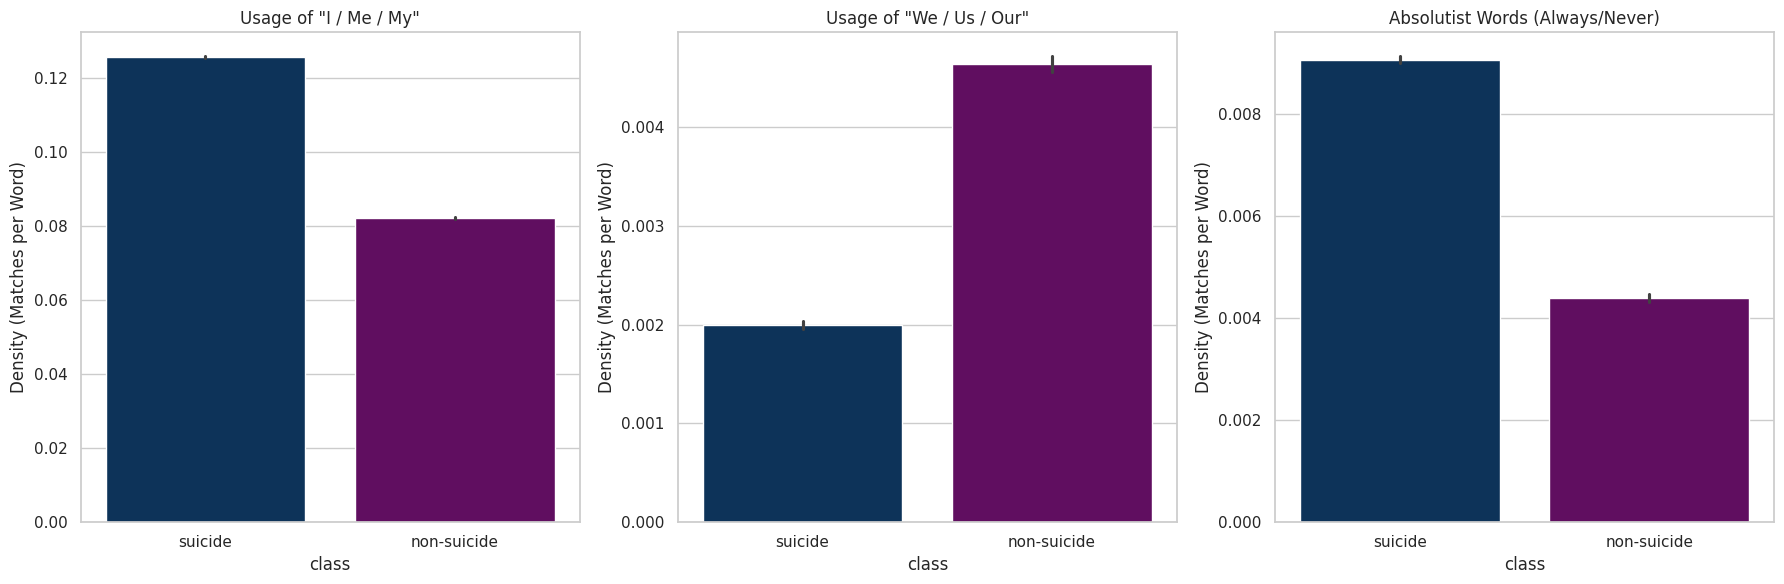

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

# ==============================================================================
# PART 1: TOPIC MODELING (LDA)
# ==============================================================================
print("🧠 PART 1: Discovering Latent Topics (LDA)...")

# 1. Vectorize (Limit to top 1000 words to keep topics sharp)
# We remove common English stop words + the "teenager" ban list if you have one
tf_vectorizer = CountVectorizer(max_df=0.95, min_df=10, max_features=1000, stop_words='english')
tf = tf_vectorizer.fit_transform(df['text_clean'])
feature_names = tf_vectorizer.get_feature_names_out()

# 2. Fit LDA Model (Let's look for 5 distinct topics)
# This finds 5 "clusters" of words that tend to appear together
n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, n_jobs=-1)
lda_output = lda.fit_transform(tf)

# 3. Display the Topics
print("\n🔍 The 5 Hidden Topics in the Dataset:")
topic_names = {}
for topic_idx, topic in enumerate(lda.components_):
    # Get top 10 words for this topic
    top_words = [feature_names[i] for i in topic.argsort()[:-11:-1]]
    topic_label = f"Topic {topic_idx+1}"
    topic_names[topic_idx] = topic_label
    print(f"   {topic_label}: {', '.join(top_words)}")

# 4. Compare Topic Distribution by Class
# We calculate which class talks about which topic more
df['dominant_topic'] = np.argmax(lda_output, axis=1)
topic_dist = pd.crosstab(df['dominant_topic'], df['class'], normalize='index')

# Visualization
topic_dist.plot(kind='bar', stacked=True, figsize=(10, 6), color=HEC_MILA_PALETTE)
plt.title('Which Class dominates which Topic?')
plt.ylabel('Proportion of Posts')
plt.xlabel('Topic Number')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
# PART 2: PSYCHOLINGUISTIC MARKERS (Pronouns & Absolutism)
# ==============================================================================
print("\n🧠 PART 2: Analyzing Cognitive Markers...")

# Define Dictionaries (Simplified versions of LIWC categories)
first_person_singular = r'\b(i|me|my|mine|myself)\b'
first_person_plural = r'\b(we|us|our|ours|ourselves)\b'
absolutist_words = r'\b(always|never|completely|totally|entirely|everyone|everything|nothing|forever)\b'

def get_marker_density(text, regex_pattern):
    if not isinstance(text, str) or len(text) == 0: return 0
    matches = len(re.findall(regex_pattern, text, flags=re.IGNORECASE))
    word_count = len(text.split())
    if word_count == 0: return 0
    return matches / word_count

# Calculate densities
df['self_ref_density'] = df['text_clean'].apply(lambda x: get_marker_density(x, first_person_singular))
df['social_ref_density'] = df['text_clean'].apply(lambda x: get_marker_density(x, first_person_plural))
df['absolutist_density'] = df['text_clean'].apply(lambda x: get_marker_density(x, absolutist_words))

# Visualization: Compare Classes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Self-Reference (The "Isolation" Marker)
sns.barplot(x='class', y='self_ref_density', data=df, ax=axes[0], palette=HEC_MILA_PALETTE)
axes[0].set_title('Usage of "I / Me / My"')
axes[0].set_ylabel('Density (Matches per Word)')

# Plot 2: Social Reference (The "Connection" Marker)
sns.barplot(x='class', y='social_ref_density', data=df, ax=axes[1], palette=HEC_MILA_PALETTE)
axes[1].set_title('Usage of "We / Us / Our"')
axes[1].set_ylabel('Density (Matches per Word)')

# Plot 3: Absolutist Thinking (The "Rigidity" Marker)
sns.barplot(x='class', y='absolutist_density', data=df, ax=axes[2], palette=HEC_MILA_PALETTE)
axes[2].set_title('Absolutist Words (Always/Never)')
axes[2].set_ylabel('Density (Matches per Word)')

plt.tight_layout()
plt.show()

# temporal and emotional analyses

In [ ]:
import nltk

# Download the specific missing resource
# 'punkt_tab' is required for newer versions of NLTK/TextBlob
nltk.download('punkt_tab')
nltk.download('punkt') # Good measure to ensure the base is there too
nltk.download('averaged_perceptron_tagger') # Often needed for POS tagging

print("✅ NLTK resources downloaded. You can now run the Emotion Analysis.")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ NLTK resources downloaded. You can now run the Emotion Analysis.


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [ ]:
# 1. Install necessary libraries
!pip install -q -U NRCLex textblob nltk

import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from nrclex import NRCLex
from math import pi
import nltk

# Download necessary NLTK / TextBlob corpora
for pkg in ["punkt", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

!python -m textblob.download_corpora lite

# Ensure Spacy is loaded
if 'nlp' not in locals():
    print("⏳ Loading Spacy model...")
    nlp = spacy.load('en_core_web_sm')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.3 MB/s eta 0:00:00
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
Finished.
⏳ Loading Spacy model...


⏳ PART 1: Analyzing Verb Tenses (Time Perception)...


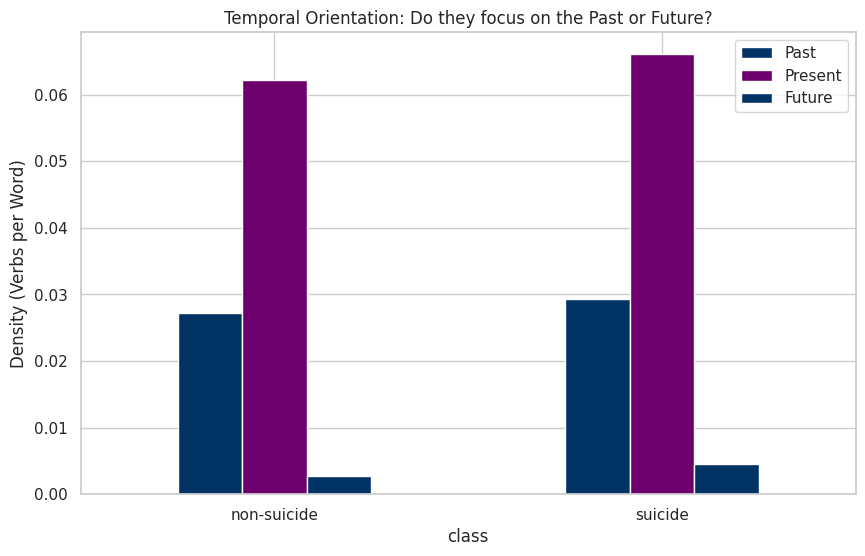


💔 PART 2: Analyzing Discrete Emotions (Radar Chart)...


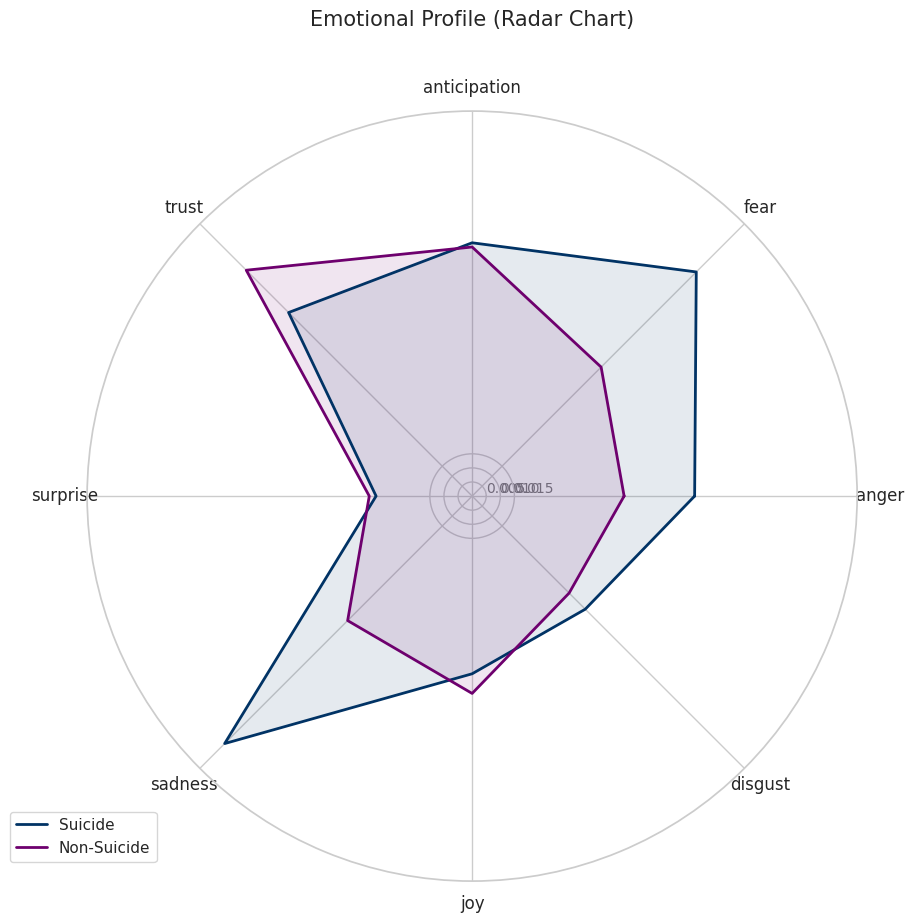

In [ ]:
# 1. Install necessary libraries
!pip install -q -U NRCLex

import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from nrclex import NRCLex
from math import pi
import nltk

# Download necessary NLTK data
nltk.download('punkt', quiet=True)

# Ensure Spacy is loaded (if not already)
if 'nlp' not in locals():
    print("⏳ Loading Spacy model...")
    nlp = spacy.load('en_core_web_sm')

# ==============================================================================
# PART 1: TEMPORAL ORIENTATION (Past vs. Future)
# ==============================================================================
print("⏳ PART 1: Analyzing Verb Tenses (Time Perception)...")

def get_verb_tenses(text):
    text = "" if pd.isna(text) else str(text)
    doc = nlp(text)
    counts = {'Past': 0, 'Present': 0, 'Future': 0}

    for token in doc:
        if token.pos_ == 'VERB':
            if 'Tense=Past' in token.morph:
                counts['Past'] += 1
            elif 'Tense=Pres' in token.morph:
                counts['Present'] += 1
        if token.lemma_ == 'will':
            counts['Future'] += 1

    total = len(doc)
    if total == 0:
        return {k: 0.0 for k in counts}
    return {k: v / total for k, v in counts.items()}

# Balanced sample without pandas deprecation warning
sample_n = min(5000, df['class'].value_counts().min())
df_sample = (
    df.groupby('class', group_keys=False)
      .sample(n=sample_n, random_state=42)
      .reset_index(drop=True)
)

# Apply tense extraction
tense_data = df_sample['text_clean'].fillna("").astype(str).apply(get_verb_tenses).apply(pd.Series)
df_sample = pd.concat([df_sample, tense_data], axis=1)

# Visualization
tense_means = df_sample.groupby('class')[['Past', 'Present', 'Future']].mean()

tense_means.plot(kind='bar', figsize=(10, 6), color=HEC_MILA_TRIPLE)
plt.title('Temporal Orientation: Do they focus on the Past or Future?')
plt.ylabel('Density (Verbs per Word)')
plt.xticks(rotation=0)
plt.show()

# ==============================================================================
# PART 2: DISCRETE EMOTION ANALYSIS (Radar Chart)
# ==============================================================================
print("\n💔 PART 2: Analyzing Discrete Emotions (Radar Chart)...")

core_emotions = ['anger', 'fear', 'anticipation', 'trust', 'surprise', 'sadness', 'joy', 'disgust']

def get_emotions(text):
    text = "" if pd.isna(text) else str(text).strip()

    if not text:
        return {emo: 0.0 for emo in core_emotions}

    # IMPORTANT FIX:
    # Use the documented API: instantiate first, then load raw text
    emotion = NRCLex()
    emotion.load_raw_text(text)

    # Prefer normalized frequencies if available
    if hasattr(emotion, "affect_frequencies"):
        scores = dict(emotion.affect_frequencies)
    elif hasattr(emotion, "raw_emotion_scores"):
        raw = dict(emotion.raw_emotion_scores)
        total = sum(raw.values())
        scores = {k: (v / total if total > 0 else 0.0) for k, v in raw.items()}
    else:
        scores = {}

    # Some NRCLex outputs may use 'anticip' instead of 'anticipation'
    if 'anticip' in scores:
        scores['anticipation'] = scores.get('anticipation', 0.0) + scores.pop('anticip')

    return {emo: float(scores.get(emo, 0.0)) for emo in core_emotions}

emotion_data = (
    df_sample['text_clean']
    .fillna("")
    .astype(str)
    .apply(get_emotions)
    .apply(pd.Series)
)

df_emotions = pd.concat(
    [df_sample[['class']].reset_index(drop=True), emotion_data.reset_index(drop=True)],
    axis=1
)

emotion_means = df_emotions.groupby('class')[core_emotions].mean()

def make_radar_chart(df_means):
    categories = list(df_means.columns)
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)

    plt.xticks(angles[:-1], categories, size=12)

    ax.set_rlabel_position(0)
    ymax = max(0.015, df_means.max().max() * 1.1)
    plt.yticks([0.005, 0.010, 0.015], ["0.005", "0.010", "0.015"], color="grey", size=10)
    plt.ylim(0, ymax)

    values_s = df_means.loc['suicide'].values.flatten().tolist()
    values_s += values_s[:1]
    ax.plot(angles, values_s, linewidth=2, linestyle='solid', label="Suicide", color=HEC_BLUE)
    ax.fill(angles, values_s, color=HEC_BLUE, alpha=0.1)

    values_ns = df_means.loc['non-suicide'].values.flatten().tolist()
    values_ns += values_ns[:1]
    ax.plot(angles, values_ns, linewidth=2, linestyle='solid', label="Non-Suicide", color=MILA_PURPLE)
    ax.fill(angles, values_ns, color=MILA_PURPLE, alpha=0.1)

    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title('Emotional Profile (Radar Chart)', size=15, y=1.1)
    plt.show()

make_radar_chart(emotion_means)

🚀 Accelerator: GPU (A100)
📦 Converting to Hugging Face Dataset format...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

🧠 Processing 232074 posts (Turbo Mode)...


Inference:   0%|          | 0/232074 [00:00<?, ?it/s]

✅ Inference Complete. Parsing...
✅ Calculating Statistics...
📉 Top 10 Emotions: disappointment, sadness, neutral, grief, nervousness, approval, fear, curiosity, admiration, amusement


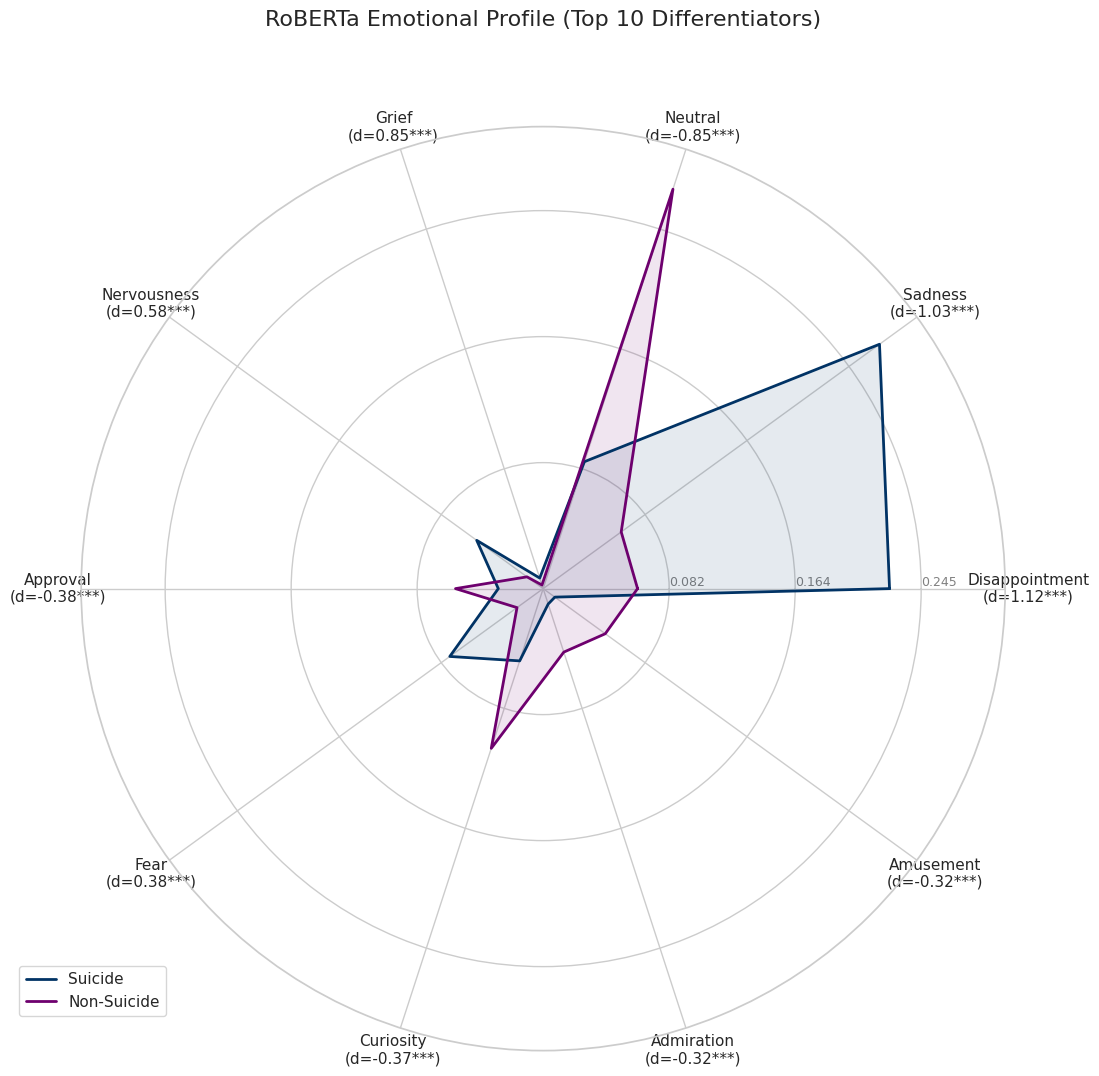

In [ ]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset # <--- CRITICAL IMPORT
from datasets import Dataset
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from scipy import stats
from math import pi
import matplotlib.pyplot as plt

# 1. SETUP
device = 0 if torch.cuda.is_available() else -1
print(f"🚀 Accelerator: {'GPU (A100)' if device == 0 else 'CPU'}")

# 2. PREPARE DATASET
print("📦 Converting to Hugging Face Dataset format...")
# Ensure strictly strings
texts = df['text_clean'].astype(str).tolist()
hf_dataset = Dataset.from_dict({"text": texts})

# 3. LOAD MODEL (FP16 + A100 Batch Size)
# We use 'dtype' instead of 'torch_dtype' to fix the warning
classifier = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None,
    truncation=True,
    batch_size=4096,  # Massive batch size for A100
    device=device,
    dtype=torch.float16 # Enable FP16 (Tensor Cores)
)

# 4. RUN INFERENCE (The "KeyDataset" Fix)
print(f"🧠 Processing {len(df)} posts (Turbo Mode)...")

raw_results = []

# KeyDataset(hf_dataset, "text") feeds the GPU directly without loading everything into RAM
for out in tqdm(classifier(KeyDataset(hf_dataset, "text"), batch_size=4096), total=len(hf_dataset), desc="Inference"):
    raw_results.append(out)

print("✅ Inference Complete. Parsing...")

# 5. PARSE & STATS
results = [{item['label']: item['score'] for item in row} for row in raw_results]
emotion_df = pd.DataFrame(results)
emotion_df['class'] = df['class'].values

print("✅ Calculating Statistics...")

stats_data = []
emotions = [col for col in emotion_df.columns if col != 'class']

for emo in emotions:
    s_scores = emotion_df[emotion_df['class'] == 'suicide'][emo]
    ns_scores = emotion_df[emotion_df['class'] == 'non-suicide'][emo]

    d = (s_scores.mean() - ns_scores.mean()) / np.sqrt((s_scores.std()**2 + ns_scores.std()**2) / 2)
    _, p_val = stats.ttest_ind(s_scores, ns_scores, equal_var=False)

    stats_data.append({
        'emotion': emo,
        'd': d,
        'abs_d': abs(d),
        'p': p_val,
        'mean_suicide': s_scores.mean(),
        'mean_nonsuicide': ns_scores.mean()
    })

# Sort and Select Top 10
stats_df = pd.DataFrame(stats_data).sort_values('abs_d', ascending=False)
top_10_emotions = stats_df.head(10)['emotion'].tolist()

print(f"📉 Top 10 Emotions: {', '.join(top_10_emotions)}")

# 6. PLOT
def make_roberta_radar(stats_df, top_n=10):
    plot_data = stats_df.head(top_n).copy()

    labels = []
    for _, row in plot_data.iterrows():
        sig = "***" if row['p'] < 0.001 else "**" if row['p'] < 0.01 else "*"
        labels.append(f"{row['emotion'].capitalize()}\n(d={row['d']:.2f}{sig})")

    categories = labels
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    plt.figure(figsize=(12, 12))
    ax = plt.subplot(111, polar=True)
    plt.xticks(angles[:-1], categories, size=11)
    ax.set_rlabel_position(0)

    max_val = max(plot_data['mean_suicide'].max(), plot_data['mean_nonsuicide'].max())
    grid_points = [max_val*0.3, max_val*0.6, max_val*0.9]
    plt.yticks(grid_points, [f"{g:.3f}" for g in grid_points], color="grey", size=9)
    plt.ylim(0, max_val * 1.1)

    values_s = plot_data['mean_suicide'].tolist() + [plot_data['mean_suicide'].tolist()[0]]
    ax.plot(angles, values_s, linewidth=2, linestyle='solid', label="Suicide", color=HEC_BLUE)
    ax.fill(angles, values_s, HEC_BLUE, alpha=0.1)

    values_ns = plot_data['mean_nonsuicide'].tolist() + [plot_data['mean_nonsuicide'].tolist()[0]]
    ax.plot(angles, values_ns, linewidth=2, linestyle='solid', label="Non-Suicide", color=MILA_PURPLE)
    ax.fill(angles, values_ns, MILA_PURPLE, alpha=0.1)

    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title(f'RoBERTa Emotional Profile (Top {top_n} Differentiators)', size=16, y=1.1)
    plt.show()

make_roberta_radar(stats_df)

# statistical power and effect analyses

## although all average differences are significant statistically between the two analysed groups (i.e. corpora), the effect is only considerable for usage of self-referal language tendencies in the suicide watch corpus. People going through suicidal ideation are in a state of crisis and need to share their feelings in order to be helped and seen.

In [ ]:
from scipy import stats
import numpy as np

def cohen_d(x, y):
    """Calculates the effect size (difference in means / pooled standard deviation)."""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    return (np.mean(x) - np.mean(y)) / np.sqrt(((nx-1)*np.std(x, ddof=1) ** 2 + (ny-1)*np.std(y, ddof=1) ** 2) / dof)

def interpret_effect(d):
    d = abs(d)
    if d < 0.2: return "Negligible"
    if d < 0.5: return "Small"
    if d < 0.8: return "Medium"
    return "Large"

# Define the metrics we want to test
metrics = ['self_ref_density', 'social_ref_density', 'absolutist_density']

print(f"{'METRIC':<20} | {'P-VALUE':<10} | {'COHEN\'S D':<10} | {'VERDICT'}")
print("-" * 65)

for metric in metrics:
    # Separate the data
    suicide_scores = df[df['class'] == 'suicide'][metric]
    nonsuicide_scores = df[df['class'] == 'non-suicide'][metric]

    # 1. Run T-Test
    t_stat, p_val = stats.ttest_ind(suicide_scores, nonsuicide_scores, equal_var=False)

    # 2. Calculate Effect Size
    d = cohen_d(suicide_scores, nonsuicide_scores)

    # Formatting for display
    p_display = "< 0.001" if p_val < 0.001 else f"{p_val:.4f}"

    print(f"{metric:<20} | {p_display:<10} | {d:.4f}     | {interpret_effect(d)}")

METRIC               | P-VALUE    | COHEN'S D  | VERDICT
-----------------------------------------------------------------
self_ref_density     | < 0.001    | 0.7934     | Medium
social_ref_density   | < 0.001    | -0.2194     | Small
absolutist_density   | < 0.001    | 0.3394     | Small


/tmp/ipykernel_589/662716078.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='self_ref_density', data=df, ax=axes[0], palette=HEC_MILA_PALETTE)
/tmp/ipykernel_589/662716078.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='social_ref_density', data=df, ax=axes[1], palette=HEC_MILA_PALETTE)
/tmp/ipykernel_589/662716078.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='absolutist_density', data=df, ax=axes[2], palette=HEC_MILA_PALETTE)


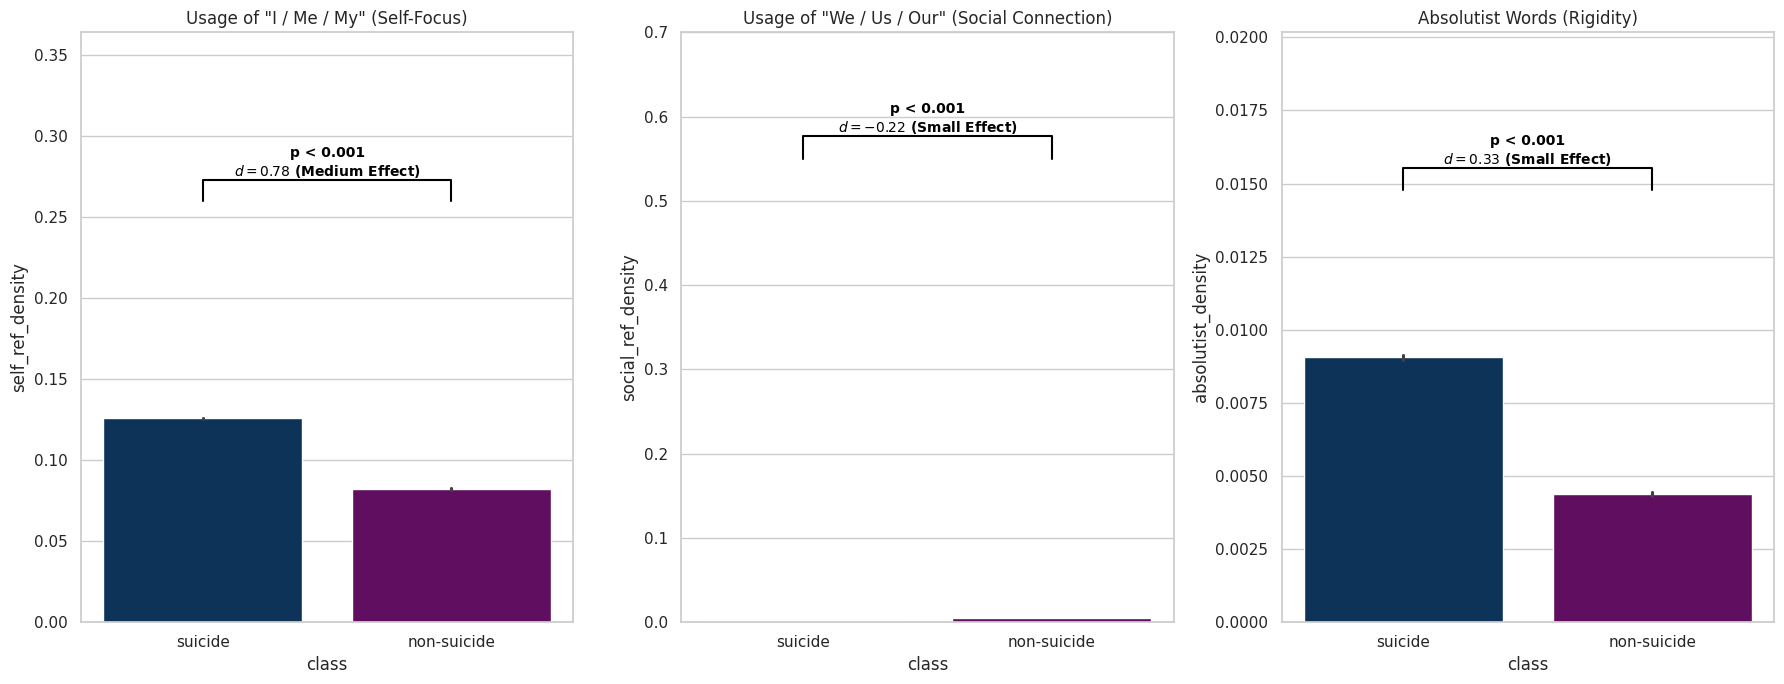

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the stats you found (Hardcoded for precision based on your table)
stats_results = {
    'self_ref_density':   {'p': '< 0.001', 'd': 0.7775, 'verdict': 'Medium Effect'},
    'social_ref_density': {'p': '< 0.001', 'd': -0.2197, 'verdict': 'Small Effect'},
    'absolutist_density': {'p': '< 0.001', 'd': 0.3329, 'verdict': 'Small Effect'}
}

def add_stat_annotation(ax, x1, x2, y, p_val, d_val, verdict):
    """
    Draws a bracket with p-value and effect size on the plot.
    """
    h = y * 0.05  # Height of the bracket legs

    # Draw the bracket (line down, line across, line down)
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='black')

    # Add the text above the bracket
    # We split it into two lines for clarity: Significance on top, Effect Size below
    label = f"p {p_val}\n$d={d_val:.2f}$ ({verdict})"

    ax.text((x1+x2)*.5, y+h, label, ha='center', va='bottom', color='black', fontsize=10, fontweight='bold')

# Setup the figure
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Plot 1: Self-Reference
sns.barplot(x='class', y='self_ref_density', data=df, ax=axes[0], palette=HEC_MILA_PALETTE)
axes[0].set_title('Usage of "I / Me / My" (Self-Focus)')
axes[0].set_ylim(0, df['self_ref_density'].mean() * 3.5) # Make room for annotation
add_stat_annotation(axes[0], 0, 1, df['self_ref_density'].mean() * 2.5,
                    stats_results['self_ref_density']['p'],
                    stats_results['self_ref_density']['d'],
                    stats_results['self_ref_density']['verdict'])

# Plot 2: Social Reference
sns.barplot(x='class', y='social_ref_density', data=df, ax=axes[1], palette=HEC_MILA_PALETTE)
axes[1].set_title('Usage of "We / Us / Our" (Social Connection)')
axes[1].set_ylim(0, df['social_ref_density'].max() * 1.4) # Make room
add_stat_annotation(axes[1], 0, 1, df['social_ref_density'].max() * 1.1,
                    stats_results['social_ref_density']['p'],
                    stats_results['social_ref_density']['d'],
                    stats_results['social_ref_density']['verdict'])

# Plot 3: Absolutist Words
sns.barplot(x='class', y='absolutist_density', data=df, ax=axes[2], palette=HEC_MILA_PALETTE)
axes[2].set_title('Absolutist Words (Rigidity)')
axes[2].set_ylim(0, df['absolutist_density'].mean() * 3.0) # Make room
add_stat_annotation(axes[2], 0, 1, df['absolutist_density'].mean() * 2.2,
                    stats_results['absolutist_density']['p'],
                    stats_results['absolutist_density']['d'],
                    stats_results['absolutist_density']['verdict'])

plt.tight_layout()
plt.show()

## the effect size of the differences for the usage of future tense between suicidal and non-suicidal corpora is small but statistically significant. Same situation with the usage of the past tense (i.e. perhaps people having depression and wanting to kill themselves reminisce more and project themselves in the future less.)  

/tmp/ipykernel_589/2785191781.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Tense', y='Density', hue='class', data=df_long, palette=HEC_MILA_PALETTE, ci=None)


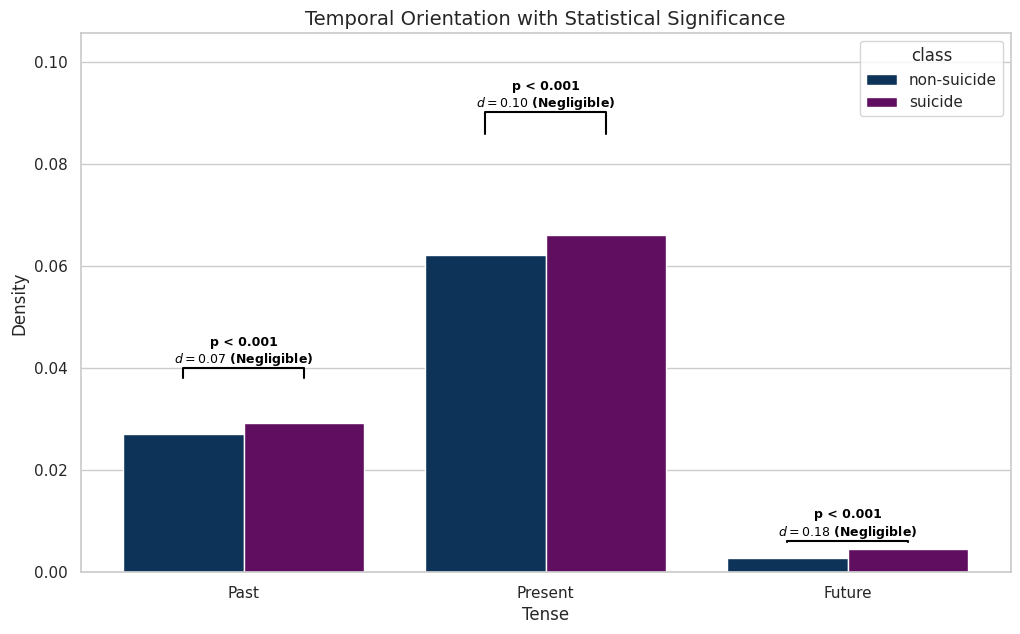

In [ ]:
from scipy import stats

# --- 1. Calculate Stats for Tenses ---
tenses = ['Past', 'Present', 'Future']
stats_results = {}

for tense in tenses:
    s_scores = df_sample[df_sample['class'] == 'suicide'][tense]
    ns_scores = df_sample[df_sample['class'] == 'non-suicide'][tense]

    # T-Test & Cohen's d
    t_stat, p_val = stats.ttest_ind(s_scores, ns_scores, equal_var=False)
    d = (s_scores.mean() - ns_scores.mean()) / np.sqrt((s_scores.std()**2 + ns_scores.std()**2) / 2)

    stats_results[tense] = {'p': p_val, 'd': d}

# --- 2. Plotting Function with Brackets ---
def plot_temporal_with_stats(df_means, raw_data, stats_data):
    # Melt for Seaborn (easier to control than pandas plot)
    df_long = raw_data.melt(id_vars='class', value_vars=['Past', 'Present', 'Future'], var_name='Tense', value_name='Density')

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(x='Tense', y='Density', hue='class', data=df_long, palette=HEC_MILA_PALETTE, ci=None)

    # Add Brackets
    # We iterate over the 3 tenses (0, 1, 2 on x-axis)
    for i, tense in enumerate(['Past', 'Present', 'Future']):
        # Get stats
        p = stats_data[tense]['p']
        d = stats_data[tense]['d']

        # Determine label text
        p_text = "p < 0.001" if p < 0.001 else f"p={p:.3f}"
        verdict = "Negligible" if abs(d) < 0.2 else "Small" if abs(d) < 0.5 else "Medium" if abs(d) < 0.8 else "Large"
        label = f"{p_text}\n$d={d:.2f}$ ({verdict})"

        # Coordinates for bracket
        # Bars are typically at x - 0.2 and x + 0.2
        x1, x2 = i - 0.2, i + 0.2
        y_max = max(raw_data[tense].max(), df_means[tense].max())
        # We use the mean + some padding for height, or max if outliers are huge
        y_h = df_means.loc[:, tense].max() * 1.3 # Bracket height

        # Draw bracket
        h = y_h * 0.05
        ax.plot([x1, x1, x2, x2], [y_h, y_h+h, y_h+h, y_h], lw=1.5, c='black')
        ax.text((x1+x2)*.5, y_h+h, label, ha='center', va='bottom', color='black', fontsize=9, fontweight='bold')

    plt.title('Temporal Orientation with Statistical Significance', fontsize=14)
    plt.ylim(0, df_means.max().max() * 1.6) # Add headroom for brackets
    plt.show()

# Run it
plot_temporal_with_stats(tense_means, df_sample, stats_results)

## Deterministic sentiment analysis (that unfortunately works with keywords / dicts and does not consider context) still gives statistically significant signal and large effects for emotions known to be correlated to suicidal ideation.

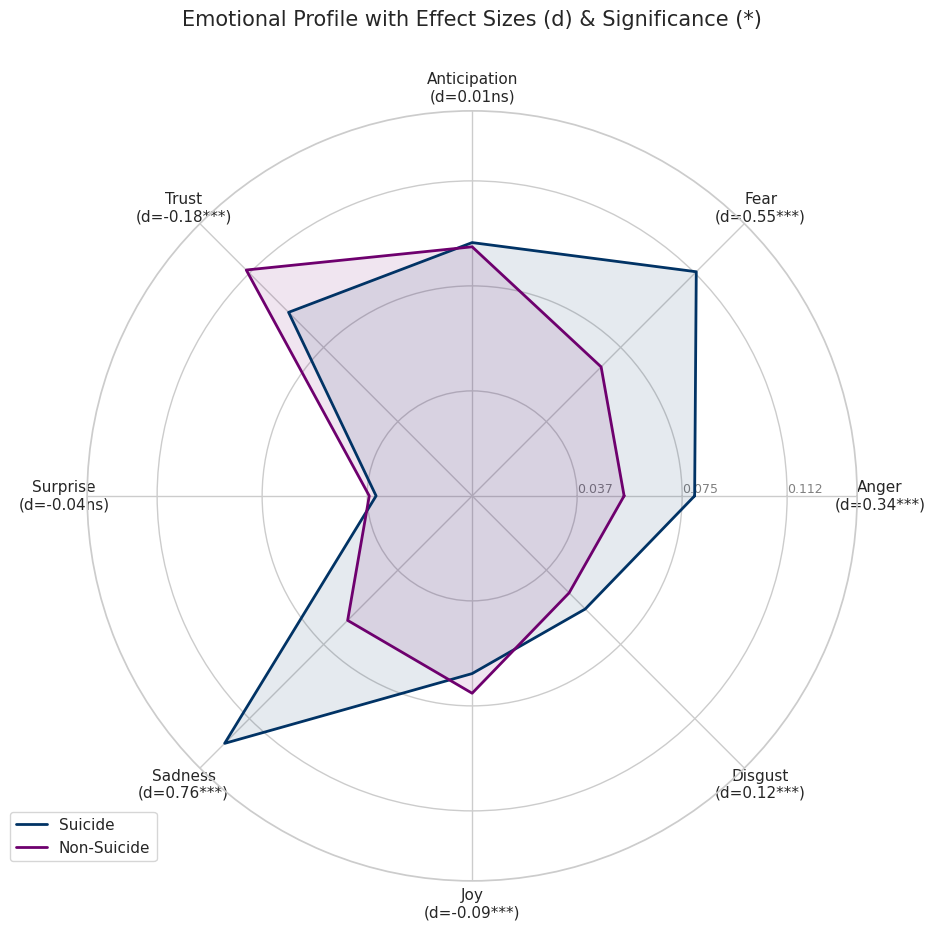

In [ ]:
# --- 1. Calculate Stats for Emotions ---
emotion_stats = {}
core_emotions = ['anger', 'fear', 'anticipation', 'trust', 'surprise', 'sadness', 'joy', 'disgust']

for emo in core_emotions:
    s_scores = df_emotions[df_emotions['class'] == 'suicide'][emo]
    ns_scores = df_emotions[df_emotions['class'] == 'non-suicide'][emo]

    t_stat, p_val = stats.ttest_ind(s_scores, ns_scores, equal_var=False)
    d = (s_scores.mean() - ns_scores.mean()) / np.sqrt((s_scores.std()**2 + ns_scores.std()**2) / 2)

    # Generate label suffix
    sig_mark = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    emotion_stats[emo] = f"\n(d={d:.2f}{sig_mark})"

# --- 2. Updated Radar Chart Function ---
def make_radar_with_stats(df_means, stats_labels):
    categories = list(df_means.columns)
    # REPLACE labels with "Label + Stat"
    cat_labels = [f"{c.capitalize()}{stats_labels[c]}" for c in categories]

    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)

    # Use new labels
    plt.xticks(angles[:-1], cat_labels, size=11)

    ax.set_rlabel_position(0)
    max_val = df_means.max().max()
    plt.yticks([max_val*0.3, max_val*0.6, max_val*0.9],
               [f"{max_val*0.3:.3f}", f"{max_val*0.6:.3f}", f"{max_val*0.9:.3f}"],
               color="grey", size=9)
    plt.ylim(0, max_val * 1.1)

    # Plot Data
    values_s = df_means.loc['suicide'].values.flatten().tolist() + [df_means.loc['suicide'].values.flatten().tolist()[0]]
    ax.plot(angles, values_s, linewidth=2, linestyle='solid', label="Suicide", color=HEC_BLUE)
    ax.fill(angles, values_s, HEC_BLUE, alpha=0.1)

    values_ns = df_means.loc['non-suicide'].values.flatten().tolist() + [df_means.loc['non-suicide'].values.flatten().tolist()[0]]
    ax.plot(angles, values_ns, linewidth=2, linestyle='solid', label="Non-Suicide", color=MILA_PURPLE)
    ax.fill(angles, values_ns, MILA_PURPLE, alpha=0.1)

    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title(f'Emotional Profile with Effect Sizes (d) & Significance (*)', size=15, y=1.1)
    plt.show()

# Run it
make_radar_with_stats(emotion_means, emotion_stats)

## Transformer based sentiment analysis (i.e. context aware) gives statistically significant signal and large effects for emotions known to be correlated to suicidal ideation.

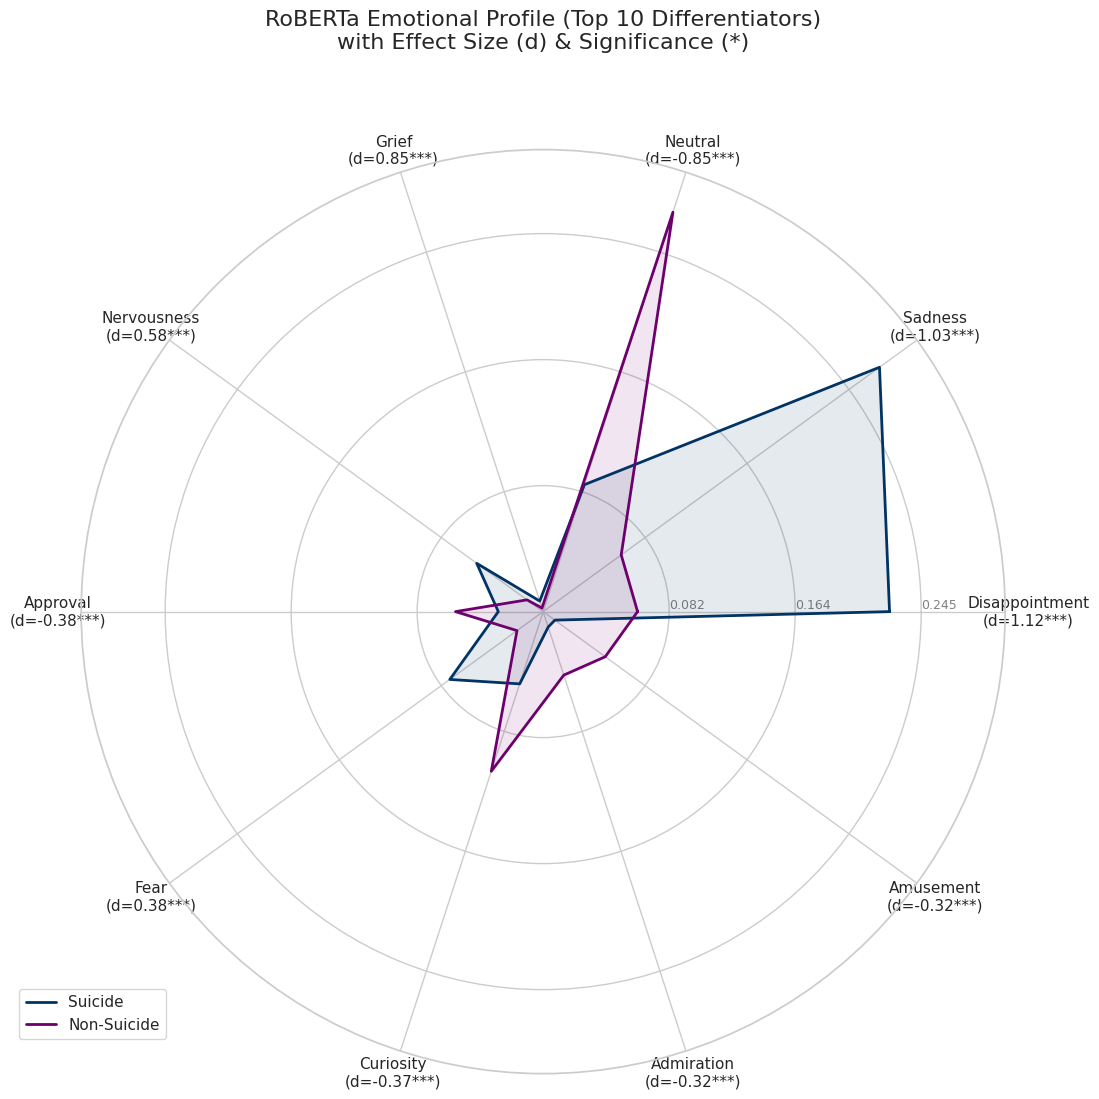

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from math import pi

# 1. CALCULATE STATS FOR ALL 28 ROBERTA EMOTIONS
# We assume 'emotion_df' is the dataframe from your RoBERTa inference
all_emotions = [col for col in emotion_df.columns if col != 'class']
stats_list = []

for emo in all_emotions:
    s_scores = emotion_df[emotion_df['class'] == 'suicide'][emo]
    ns_scores = emotion_df[emotion_df['class'] == 'non-suicide'][emo]

    # Calculate t-stat and p-value
    t_stat, p_val = stats.ttest_ind(s_scores, ns_scores, equal_var=False)

    # Calculate Cohen's d
    pooled_std = np.sqrt((s_scores.std()**2 + ns_scores.std()**2) / 2)
    d = (s_scores.mean() - ns_scores.mean()) / pooled_std

    # Store for sorting
    stats_list.append({
        'emotion': emo,
        'd': d,
        'abs_d': abs(d),
        'p': p_val,
        'mean_suicide': s_scores.mean(),
        'mean_nonsuicide': ns_scores.mean()
    })

# 2. FILTER: KEEP ONLY TOP 10 DIFFERENTIATORS
# We sort by absolute effect size to find the most "important" emotions
top_stats = pd.DataFrame(stats_list).sort_values('abs_d', ascending=False).head(10)
top_emotions = top_stats['emotion'].tolist()

# 3. PREPARE DATA FOR YOUR PLOTTING FUNCTION
# Create the 'means' dataframe for just the top 10
df_means = emotion_df.groupby('class')[top_emotions].mean()

# Create the 'stats_labels' dictionary for just the top 10
stats_labels = {}
for _, row in top_stats.iterrows():
    p_val = row['p']
    d = row['d']
    sig_mark = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    stats_labels[row['emotion']] = f"\n(d={d:.2f}{sig_mark})"

# 4. YOUR PLOTTING FUNCTION (Unchanged logic, just applied to new data)
def make_radar_with_stats(df_means, stats_labels):
    categories = list(df_means.columns)
    cat_labels = [f"{c.capitalize()}{stats_labels[c]}" for c in categories]

    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    plt.figure(figsize=(12, 12)) # Slightly larger for the extra text
    ax = plt.subplot(111, polar=True)

    plt.xticks(angles[:-1], cat_labels, size=11)

    ax.set_rlabel_position(0)
    max_val = df_means.max().max()

    # Dynamic grid lines based on max value
    grid_points = [max_val*0.3, max_val*0.6, max_val*0.9]
    plt.yticks(grid_points, [f"{g:.3f}" for g in grid_points], color="grey", size=9)
    plt.ylim(0, max_val * 1.1)

    # Plot Suicide
    values_s = df_means.loc['suicide'].values.flatten().tolist()
    values_s += values_s[:1]
    ax.plot(angles, values_s, linewidth=2, linestyle='solid', label="Suicide", color=HEC_BLUE)
    ax.fill(angles, values_s, HEC_BLUE, alpha=0.1)

    # Plot Non-Suicide
    values_ns = df_means.loc['non-suicide'].values.flatten().tolist()
    values_ns += values_ns[:1]
    ax.plot(angles, values_ns, linewidth=2, linestyle='solid', label="Non-Suicide", color=MILA_PURPLE)
    ax.fill(angles, values_ns, MILA_PURPLE, alpha=0.1)

    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title(f'RoBERTa Emotional Profile (Top 10 Differentiators)\nwith Effect Size (d) & Significance (*)', size=16, y=1.1)
    plt.show()

# Run it
make_radar_with_stats(df_means, stats_labels)